# Data Injection #
**Description**
This Jupyter notebook is used to inject Data in excel or CSV format into firebase DB 

In [1]:

!pip install pandas --quiet
!pip install geopy --quiet
!pip -q install pycountry --quiet

In [2]:

import pandas as pd
import re
import numpy as np
import pandas as pd
import pycountry
import matplotlib.pyplot as plt
data_path = './dataset'


## Feature Engineering Configuration

Configuration constants for comprehensive feature engineering pipeline.

## Load the Transport Cost Data


In [3]:
# TRANSPORT_PATH = f"{data_path}/TransportCosts.csv"
TRANSPORT_PATH = f"{data_path}/transport_cost_by_product.csv"
LSCI_PATH      = f"{data_path}/LSCI.csv"
LSBCI_PATH     = f"{data_path}/LSBCI.csv"
DIST_PATH      = f"{data_path}/dist_cepii.csv"
FUEL_PATH      = f"{data_path}/Daily_Bunker_Fuel_Prices.csv"


In [4]:
# -------------------------
# (B) ISO3 mapping helper
# -------------------------
manual_iso3 = {
  'Brunei Darussalam': 'BRN',
  'Cabo Verde': 'CPV',
  'China, Hong Kong SAR': 'HKG',
  'China, Macao SAR': 'MAC',
  'China, Taiwan Province of': 'TWN',
  'Congo, Dem. Rep. of the': 'COD',
  "Cote d'Ivoire": 'CIV',
  'Curaçao': 'CUW',
  'Curacao': 'CUW',
  'Eswatini': 'SWZ',
  "Korea, Dem. People's Rep. of": 'PRK',
  "Lao People's Dem. Rep.": 'LAO',
  'Netherlands (Kingdom of the)': 'NLD',
  'Russian Federation': 'RUS',
  'State of Palestine': 'PSE',
  'Türkiye': 'TUR',
  'Turkiye': 'TUR',
  'Venezuela (Bolivarian Rep. of)': 'VEN',
  'Viet Nam': 'VNM',
  'Bolivia (Plurinational State of)': 'BOL',
  'Iran (Islamic Republic of)': 'IRN',
  'Syrian Arab Republic': 'SYR',
  'United Republic of Tanzania': 'TZA',
  'Micronesia (Federated States of)': 'FSM',
  'Dem. Rep. of the Congo': 'COD',
  'Democratic Republic of the Congo': 'COD',
  "Côte d'Ivoire": 'CIV',
  "Côte d'Ivoire": 'CIV',
}

def to_iso3(label: str):
    if pd.isna(label):
        return None
    s = str(label).strip()
    if s in manual_iso3:
        return manual_iso3[s]
    # minimal normalization
    repl = {
        "Côte d'Ivoire": "Cote d'Ivoire",
        "Côte d'Ivoire": "Cote d'Ivoire",
    }
    s2 = repl.get(s, s)
    try:
        return pycountry.countries.lookup(s2).alpha_3
    except Exception:
        return None

# -------------------------
# (C) Load + melt transport costs (wide -> long)
# -------------------------
YEAR_RE = re.compile(r"(20\d{2})_Advalorem_freight_rate_Value")

t = pd.read_csv(TRANSPORT_PATH)
year_cols = [c for c in t.columns if YEAR_RE.search(c)]
t.head()
if not year_cols:
    raise ValueError("No year columns matched pattern: 20xx_Advalorem_freight_rate_Value")

df_long = t.melt(
    id_vars=["Origin_Label","Destination_Label","Product_Code","Product_Label"],
    value_vars=year_cols,
    var_name="YearCol",
    value_name="Advalorem_freight_rate_Value"
)
df_long["Year"] = df_long["YearCol"].str.extract(r"(20\d{2})").astype(int)
df_long.drop(columns=["YearCol"], inplace=True)

df_obs = df_long.dropna(subset=["Advalorem_freight_rate_Value"]).copy()
df_obs["Advalorem_freight_rate_Value"] = pd.to_numeric(df_obs["Advalorem_freight_rate_Value"], errors="coerce")
df_obs = df_obs.dropna(subset=["Advalorem_freight_rate_Value"])
df_obs = df_obs[df_obs["Advalorem_freight_rate_Value"] >= 0].copy()
df_obs["y_log"] = np.log1p(df_obs["Advalorem_freight_rate_Value"])

# ISO codes for joining externals
df_obs["iso_o"] = df_obs["Origin_Label"].map(to_iso3)
df_obs["iso_d"] = df_obs["Destination_Label"].map(to_iso3)

df_obs

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d
4,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS
5,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS
7,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT
8,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT
10,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR
...,...,...,...,...,...,...,...,...,...
375511,Zimbabwe,United Kingdom,3304,"Cosmetic and toilet preparations; beauty, make...",0.056,2021,0.054488,ZWE,GBR
375514,Zimbabwe,United States of America,3304,"Cosmetic and toilet preparations; beauty, make...",0.034,2021,0.033435,ZWE,USA
375517,Zimbabwe,Zambia,2106,Food preparations not elsewhere specified or i...,0.107,2021,0.101654,ZWE,ZMB
375519,Zimbabwe,Zambia,6109,"T-shirts, singlets and other vests; knitted or...",0.607,2021,0.474369,ZWE,ZMB


## Show Missing Destination Countries


In [5]:

# Get unique country sets from origin and destination
orig_countries = set(df_obs["Origin_Label"].unique())
dest_countries = set(df_obs["Destination_Label"].unique())

# Full master list of countries
all_countries = sorted(orig_countries | dest_countries)

# Build table
country_table = pd.DataFrame({"Country": all_countries})

# ISO3 code for each country
country_table["ISO3"] = country_table["Country"].map(to_iso3)


# Put the country name in Origin_Label / Destination_Label only if it appears there, else NaN
country_table["Origin_Label"] = country_table["Country"].where(
    country_table["Country"].isin(orig_countries)
)
country_table["Destination_Label"] = country_table["Country"].where(
    country_table["Country"].isin(dest_countries)
)
# country_table
print("These are the countries whereby no routes have them as destination")
country_table[country_table["Destination_Label"].isna()]



These are the countries whereby no routes have them as destination


,Country,ISO3,Origin_Label,Destination_Label
3,American Samoa,ASM,American Samoa,NaN
6,Anguilla,AIA,Anguilla,NaN
16,Bangladesh,BGD,Bangladesh,NaN
23,Bhutan,BTN,Bhutan,NaN
25,"Bonaire, Sint Eustatius and Saba",BES,"Bonaire, Sint Eustatius and Saba",NaN
29,British Virgin Islands,VGB,British Virgin Islands,NaN
37,Canada,CAN,Canada,NaN
40,Chad,TCD,Chad,NaN
45,"China, Taiwan Province of",TWN,"China, Taiwan Province of",NaN
46,Christmas Island,CXR,Christmas Island,NaN


## Load LSCI

**LSCI (Liner Shipping Connectivity Index)** is a country-level indicator that measures how well countries are connected to global liner shipping networks. Higher values indicate better integration into global maritime trade networks through container liner services. This index is used as a feature to help predict freight rates, since countries with better shipping connectivity typically have lower transport costs and more route options.

In [6]:
lsci = pd.read_csv(LSCI_PATH)

lsci
val_candidates = [c for c in lsci.columns if c.endswith("_Value")]

# sanity check: there should be only 1 column that ends with "_Value"
LSCI_VAL_COL = val_candidates[0]

# Extract year from Quarter_Label, convert LSCI value to numeric, and keep only relevant columns
lsci2 = lsci[["Economy_Label","Quarter_Label", LSCI_VAL_COL]].copy()
lsci2["Year"] = lsci2["Quarter_Label"].astype(str).str.extract(r"(20\d{2})").astype(int)
lsci2[LSCI_VAL_COL] = pd.to_numeric(lsci2[LSCI_VAL_COL], errors="coerce")

# Average LSCI per year per country computed from quarterly data, then mapped to ISO3 code
lsci_year = (
    lsci2.groupby(["Economy_Label","Year"], as_index=False)[LSCI_VAL_COL]
    .mean()
    .rename(columns={LSCI_VAL_COL:"lsci"})
)
lsci_year["iso3"] = lsci_year["Economy_Label"].map(to_iso3)
lsci_year
lsci_global_mean = float(lsci_year["lsci"].mean())


# Join to df_obs
tmp = df_obs.merge(
    lsci_year.rename(columns={"iso3":"iso_o","lsci":"lsci_o"})[["iso_o","Year","lsci_o"]],
    on=["iso_o","Year"], how="left"
).merge(
    lsci_year.rename(columns={"iso3":"iso_d","lsci":"lsci_d"})[["iso_d","Year","lsci_d"]],
    on=["iso_d","Year"], how="left"
)


# fill missing LSCI values with global mean, then compute sum and gap
# tmp["lsci_o"] = tmp["lsci_o"].fillna(lsci_global_mean)
# tmp["lsci_d"] = tmp["lsci_d"].fillna(lsci_global_mean)
# tmp["lsci_sum"] = tmp["lsci_o"] + tmp["lsci_d"]
# tmp["lsci_gap"] = (tmp["lsci_o"] - tmp["lsci_d"]).abs()

tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d,lsci_o,lsci_d
0,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS,NaN,156.5775
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS,NaN,156.5775
2,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT,NaN,NaN
3,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT,NaN,NaN
4,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR,NaN,44.2250
...,...,...,...,...,...,...,...,...,...,...,...
277058,Zimbabwe,United Kingdom,3304,"Cosmetic and toilet preparations; beauty, make...",0.056,2021,0.054488,ZWE,GBR,NaN,384.4375
277059,Zimbabwe,United States of America,3304,"Cosmetic and toilet preparations; beauty, make...",0.034,2021,0.033435,ZWE,USA,NaN,517.3300
277060,Zimbabwe,Zambia,2106,Food preparations not elsewhere specified or i...,0.107,2021,0.101654,ZWE,ZMB,NaN,NaN
277061,Zimbabwe,Zambia,6109,"T-shirts, singlets and other vests; knitted or...",0.607,2021,0.474369,ZWE,ZMB,NaN,NaN


## Load LSBCI

**LSBCI (Liner Shipping Bilateral Connectivity Index)** measures the strength of shipping connectivity between pairs of countries (bilateral relationships). Unlike LSCI which is a country-level index, LSBCI captures the direct shipping links between origin and destination countries. Higher LSBCI values indicate stronger bilateral shipping connections, which typically result in lower freight costs and more efficient trade routes between those specific country pairs.

In [7]:
lsbci = pd.read_csv(LSBCI_PATH)

lsbci

LSBCI_VAL_COL = [c for c in lsbci.columns if c.endswith("Index_Value")][0]

lsbci2 = lsbci[["Economy_Label","Partner_Label", LSBCI_VAL_COL]].copy()

lsbci2[LSBCI_VAL_COL] = pd.to_numeric(lsbci2[LSBCI_VAL_COL], errors="coerce")
lsbci2["iso_o"] = lsbci2["Economy_Label"].map(to_iso3)
lsbci2["iso_d"] = lsbci2["Partner_Label"].map(to_iso3)
lsbci2 = lsbci2.rename(columns={LSBCI_VAL_COL:"lsbci"})[["iso_o","iso_d","lsbci"]].dropna(subset=["iso_o","iso_d"])
lsbci2 = lsbci2.groupby(["iso_o","iso_d"], as_index=False)["lsbci"].mean()

tmp = tmp.merge(lsbci2, on=["iso_o","iso_d"], how="left")

# # fill missing
# tmp["lsbci"] = tmp["lsbci"].fillna(0.0)
tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsbci
0,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS,NaN,156.5775,NaN
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS,NaN,156.5775,NaN
2,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT,NaN,NaN,NaN
3,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT,NaN,NaN,NaN
4,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR,NaN,44.2250,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
277058,Zimbabwe,United Kingdom,3304,"Cosmetic and toilet preparations; beauty, make...",0.056,2021,0.054488,ZWE,GBR,NaN,384.4375,NaN
277059,Zimbabwe,United States of America,3304,"Cosmetic and toilet preparations; beauty, make...",0.034,2021,0.033435,ZWE,USA,NaN,517.3300,NaN
277060,Zimbabwe,Zambia,2106,Food preparations not elsewhere specified or i...,0.107,2021,0.101654,ZWE,ZMB,NaN,NaN,NaN
277061,Zimbabwe,Zambia,6109,"T-shirts, singlets and other vests; knitted or...",0.607,2021,0.474369,ZWE,ZMB,NaN,NaN,NaN


## Load Distance

In [8]:
dist = pd.read_csv(DIST_PATH)


dist

# convert "." to NaN then numeric
for c in ["distw","distwces","dist","distcap"]:
    if c in dist.columns:
        dist[c] = pd.to_numeric(dist[c].replace(".", np.nan), errors="coerce")


# choose best distance
if "distw" in dist.columns:
    dist["dist_km"] = dist["distw"].fillna(dist.get("dist", np.nan))
else:
    dist["dist_km"] = dist.get("dist", np.nan)

# sanity check: there should be no zero or negative distances, if any, set to NaN
dist2 = dist[["iso_o","iso_d","dist_km"]].dropna(subset=["iso_o","iso_d"]).copy()
dist2.loc[dist2["dist_km"] <= 0, "dist_km"] = np.nan
dist_median = float(dist2["dist_km"].median())

tmp = tmp.merge(dist2, on=["iso_o","iso_d"], how="left")
print("Distance coverage (pre-fill):", tmp["dist_km"].notna().mean())

# Load country centroids for geographic distance calculation
centroids_path = f"{data_path}/country_centroids.csv"

from geopy.distance import geodesic

centroids = pd.read_csv(centroids_path)
centroids["iso3"] = centroids["Country"].map(to_iso3)

# Clean centroids: keep only rows with valid ISO3 codes and finite coordinates
centroids = centroids.dropna(subset=["iso3", "Lat", "Lon"])
centroids = centroids[
    (centroids["Lat"].notna()) & 
    (centroids["Lon"].notna()) &
    (np.isfinite(centroids["Lat"])) &
    (np.isfinite(centroids["Lon"]))
].copy()

# Create lookup dictionaries for coordinates
centroid_coords = dict(zip(centroids["iso3"], zip(centroids["Lat"], centroids["Lon"])))

print(f"Loaded {len(centroid_coords)} country centroids for distance calculation")

# Function to calculate geodesic distance
def calculate_geodesic_distance(iso_o, iso_d):
    # Check if both ISO codes are valid (not NaN) and exist in our lookup
    if pd.notna(iso_o) and pd.notna(iso_d) and iso_o in centroid_coords and iso_d in centroid_coords:
        origin_coords = centroid_coords[iso_o]
        dest_coords = centroid_coords[iso_d]
        # Double-check coordinates are finite before passing to geodesic
        if all(np.isfinite(c) for c in origin_coords + dest_coords):
            return geodesic(origin_coords, dest_coords).kilometers
    return np.nan

# Fill missing distances with calculated geographic distances
mask = tmp["dist_km"].isna()
if mask.sum() > 0:
    print(f"Calculating geographic distances for {mask.sum()} missing values...")
    tmp.loc[mask, "dist_km"] = tmp[mask].apply(
        lambda row: calculate_geodesic_distance(row["iso_o"], row["iso_d"]), 
        axis=1
    )
    print(f"Distance coverage (after centroid calculation):", tmp["dist_km"].notna().mean())

missing = tmp["dist_km"].isna().sum()
print(f"Number of missing distances after geographic calculation: {missing}")

# Fill any remaining missing distances with median
# tmp["dist_km"] = tmp["dist_km"].fillna(dist_median)
# tmp["log_dist"] = np.log1p(tmp["dist_km"])



# print(f"Final distance coverage: {tmp['dist_km'].notna().mean():.2%}")
# print(f"Distance statistics: min={tmp['dist_km'].min():.1f}, median={tmp['dist_km'].median():.1f}, max={tmp['dist_km'].max():.1f}")


Distance coverage (pre-fill): 0.7941262456553203
Loaded 211 country centroids for distance calculation
Calculating geographic distances for 57040 missing values...
Distance coverage (after centroid calculation): 0.8345033440047931
Number of missing distances after geographic calculation: 45853


## Load Fuel

**VLSFO (Very Low Sulfur Fuel Oil)** is a marine fuel with a maximum sulfur content of 0.5%, mandated by the International Maritime Organization (IMO) 2020 regulations. Prior to 2020, ships used higher sulfur fuels (up to 3.5% sulfur). VLSFO pricing directly affects shipping costs, as fuel represents a significant portion of total freight expenses. This feature captures fuel price fluctuations over time as a key cost driver in freight rate predictions.

In [9]:

fuel = pd.read_csv(FUEL_PATH)

# detect VLSFO column
fuel_candidates = [c for c in fuel.columns if "VLSFO" in c]
FUEL_COL = fuel_candidates[0]

fuel[FUEL_COL] = pd.to_numeric(fuel[FUEL_COL].replace(r"[\$,]", "", regex=True), errors="coerce")
fuel_year = (
    fuel.groupby("Year", as_index=False)[FUEL_COL].mean()
    .rename(columns={FUEL_COL:"fuel_vlsfo_avg"})
)

# Fill 2016-2018 using 2019 average (Option B)
fuel_2019 = fuel_year.loc[fuel_year["Year"] == 2019, "fuel_vlsfo_avg"]
fuel_fill = float(fuel_2019.iloc[0]) if len(fuel_2019) else float(fuel_year["fuel_vlsfo_avg"].mean())

for y in [2016, 2017, 2018]:
    if y not in set(fuel_year["Year"]):
        fuel_year = pd.concat([fuel_year, pd.DataFrame({"Year":[y], "fuel_vlsfo_avg":[fuel_fill]})], ignore_index=True)

fuel_year = fuel_year.sort_values("Year").reset_index(drop=True)

tmp = tmp.merge(fuel_year, on="Year", how="left")
# tmp["fuel_vlsfo_avg"] = tmp["fuel_vlsfo_avg"].fillna(fuel_fill)


## Load CPI data by source and destination country

**CPI (Consumer Price Index)** measures the average change over time in the prices paid by consumers for a basket of goods and services. The annual average growth rate indicates inflation levels in each country. In freight modeling, CPI is important because inflation affects purchasing power, production costs, and ultimately trade volumes between countries. Higher inflation in source or destination countries can influence freight demand and pricing dynamics.

In [10]:
cpi_data_path = f"{data_path}/CPI.csv"
df_cpi = pd.read_csv(cpi_data_path)

# Drop aggregate row that is not a real economy
df_cpi = df_cpi[df_cpi["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_cpi["Year"] = pd.to_numeric(df_cpi["Year"], errors="coerce")
df_cpi = df_cpi.dropna(subset=["Year"])
df_cpi["Year"] = df_cpi["Year"].astype(int)

# Keep only the columns we need
df_cpi = df_cpi[["Economy_Label", "Year", "Annual_average_growth_rate_Value"]].copy()

# Merge source-country CPI onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_cpi.rename(columns={"Annual_average_growth_rate_Value": "Source_CPI_Annual_average_growth_rate_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Merge destination-country CPI onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_cpi.rename(columns={"Annual_average_growth_rate_Value": "Destination_CPI_Annual_average_growth_rate_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])


## Load GDP data by source and destination country

**GDP (Gross Domestic Product)** is the total monetary value of all goods and services produced within a country over a specific time period. It's the primary indicator of economic size and activity. In freight modeling, GDP is crucial because larger economies typically generate more trade volumes, have greater import/export capacity, and can afford higher shipping costs. The GDP of both source and destination countries helps predict trade intensity and freight demand on specific routes.

In [11]:
gdp_data_path = f"{data_path}/GDP.csv"
df_gdp = pd.read_csv(gdp_data_path)

# Drop aggregate row that is not a real economy
df_gdp = df_gdp[df_gdp["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_gdp["Year"] = pd.to_numeric(df_gdp["Year"], errors="coerce")
df_gdp = df_gdp.dropna(subset=["Year"])
df_gdp["Year"] = df_gdp["Year"].astype(int)

# Keep only columns we need
df_gdp = df_gdp[["Economy_Label", "Year", "US_at_current_prices_in_millions_Value"]].copy()

# Merge source-country GDP onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_gdp.rename(columns={"US_at_current_prices_in_millions_Value": "Source_GDP_US_at_current_prices_in_millions_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Merge destination-country GDP onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_gdp.rename(columns={"US_at_current_prices_in_millions_Value": "Destination_GDP_US_at_current_prices_in_millions_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])


## Load GNI data by source and destination country

**GNI (Gross National Income)** is the total income earned by a country's residents and businesses, including income from abroad, minus income paid to foreign entities. While GDP measures production within borders, GNI measures income belonging to a country's residents regardless of location. In freight modeling, GNI reflects a country's overall purchasing power and economic capacity for international trade, making it a complementary indicator to GDP for understanding trade potential and freight demand patterns.

In [12]:
gni_data_path = f"{data_path}/GNI.csv"
df_gni = pd.read_csv(gni_data_path)

# Drop aggregate row that is not a real economy
df_gni = df_gni[df_gni["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_gni["Year"] = pd.to_numeric(df_gni["Year"], errors="coerce")
df_gni = df_gni.dropna(subset=["Year"])
df_gni["Year"] = df_gni["Year"].astype(int)

# Keep only columns we need
df_gni = df_gni[["Economy_Label", "Year", "US_dollars_at_current_prices_in_millions_Value"]].copy()

# Merge source-country GNI onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_gni.rename(columns={"US_dollars_at_current_prices_in_millions_Value": "Source_GNI_US_dollars_at_current_prices_in_millions_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

 # Merge destination-country GNI onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_gni.rename(columns={"US_dollars_at_current_prices_in_millions_Value": "Destination_GNI_US_dollars_at_current_prices_in_millions_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])


## Load Port Throughput (TEU) Data

**TEU (Twenty-foot Equivalent Unit)** is the standard unit for measuring container port throughput capacity. It represents the volume of 20-foot shipping containers handled by a port. Higher TEU throughput indicates larger, more active ports with better infrastructure, which typically correlates with lower freight costs and more efficient shipping operations.

In [13]:
teu_path = f"{data_path}/container_port_throughput.csv"
# teu_path
# # Drop existing TEU columns if they exist (for idempotency)
# teu_cols = ['origin_teu', 'dest_teu', 'origin_teu_is_imputed', 'dest_teu_is_imputed', 'teu_log_product']
# tmp = tmp.drop(columns=[col for col in teu_cols if col in tmp.columns])

df_teu_raw = pd.read_csv(teu_path)
df_teu_raw = df_teu_raw[df_teu_raw["Economy_Label"] != "Individual economies"].copy()
df_teu_raw
# Extract year columns
teu_year_cols = [c for c in df_teu_raw.columns if "TEU_Twenty_foot_Equivalent_Unit_Value" in c and c[:4].isdigit()]

# Melt to long format
df_teu = df_teu_raw.melt(
    id_vars=["Economy_Label"],
    value_vars=teu_year_cols,
    var_name="_raw_col",
    value_name="teu"
)
df_teu["Year"] = df_teu["_raw_col"].str[:4].astype(int)
df_teu = df_teu[["Economy_Label", "Year", "teu"]].copy()
df_teu["teu"] = pd.to_numeric(df_teu["teu"], errors="coerce")


# Normalize country names
df_teu["iso3"] = df_teu["Economy_Label"].map(to_iso3)
df_teu = df_teu.dropna(subset=["iso3"])
df_teu
# Merge for origin
tmp = tmp.merge(
    df_teu.rename(columns={"iso3": "iso_o", "teu": "origin_teu"})[["iso_o", "Year", "origin_teu"]],
    on=["iso_o", "Year"],
    how="left"
)
# tmp["origin_teu_is_imputed"] = tmp["origin_teu"].isna().astype(int)

# Merge for destination
tmp = tmp.merge(
    df_teu.rename(columns={"iso3": "iso_d", "teu": "dest_teu"})[["iso_d", "Year", "dest_teu"]],
    on=["iso_d", "Year"],
    how="left"
)
# tmp["dest_teu_is_imputed"] = tmp["dest_teu"].isna().astype(int)

# # Fill missing with 0
# tmp["origin_teu"] = tmp["origin_teu"].fillna(0.0)
# tmp["dest_teu"] = tmp["dest_teu"].fillna(0.0)

# # Create derived feature: teu_log_product
# tmp["teu_log_product"] = np.log1p(tmp["origin_teu"]) * np.log1p(tmp["dest_teu"])

# print(f"TEU features added - Origin coverage: {(tmp['origin_teu_is_imputed'] == 0).mean():.2%}, Dest coverage: {(tmp['dest_teu_is_imputed'] == 0).mean():.2%}")



## Load Seaborne Trade Data

**Seaborne Trade** data captures the volume of cargo loaded and discharged at each country's ports, measured in thousands of metric tons. This reflects actual trade activity and port utilization. The difference between loaded and discharged volumes (trade imbalance) can indicate whether a country is primarily an exporter or importer, affecting return leg pricing and container repositioning costs.

In [14]:
trade_path = f"{data_path}/seaborne_trade.csv"
df_trade_raw = pd.read_csv(trade_path)
df_trade_raw = df_trade_raw[df_trade_raw["Economy_Label"] != "Individual economies"].copy()
df_trade_raw = df_trade_raw.rename(columns={"CargoType_Label": "cargo_type"})

# Extract year columns
trade_year_cols = [c for c in df_trade_raw.columns if "Metric_tons_in_thousands_Value" in c and c[:4].isdigit()]

# Melt to long format
df_trade = df_trade_raw.melt(
    id_vars=["Economy_Label", "cargo_type"],
    value_vars=trade_year_cols,
    var_name="_raw_col",
    value_name="volume_kt"
)
df_trade["Year"] = df_trade["_raw_col"].str[:4].astype(int)
df_trade["volume_kt"] = pd.to_numeric(df_trade["volume_kt"], errors="coerce")

# Pivot to get loaded and discharged
df_trade_pivot = df_trade.pivot_table(
    index=["Economy_Label", "Year"],
    columns="cargo_type",
    values="volume_kt",
    aggfunc="sum"
).reset_index()
df_trade_pivot.columns.name = None

# Identify loaded/discharged columns
rename_map = {}
for c in df_trade_pivot.columns:
    if isinstance(c, str):
        if "loaded" in c.lower() and "discharged" not in c.lower():
            rename_map[c] = "loaded_kt"
        elif "discharged" in c.lower():
            rename_map[c] = "discharged_kt"

df_trade_pivot = df_trade_pivot.rename(columns=rename_map)
for col in ["loaded_kt", "discharged_kt"]:
    if col not in df_trade_pivot.columns:
        df_trade_pivot[col] = 0.0

# Normalize country names
df_trade_pivot["iso3"] = df_trade_pivot["Economy_Label"].map(to_iso3)
df_trade_pivot = df_trade_pivot.dropna(subset=["iso3"])

# Merge for origin and destination
tmp = tmp.merge(
    df_trade_pivot.rename(columns={
        "iso3": "iso_o",
        "loaded_kt": "origin_loaded_kt",
        "discharged_kt": "origin_discharged_kt"
    })[["iso_o", "Year", "origin_loaded_kt", "origin_discharged_kt"]],
    on=["iso_o", "Year"],
    how="left"
).merge(
    df_trade_pivot.rename(columns={
        "iso3": "iso_d",
        "loaded_kt": "dest_loaded_kt",
        "discharged_kt": "dest_discharged_kt"
    })[["iso_d", "Year", "dest_loaded_kt", "dest_discharged_kt"]],
    on=["iso_d", "Year"],
    how="left"
)

# # Fill missing with 0
# for col in ["origin_loaded_kt", "origin_discharged_kt", "dest_loaded_kt", "dest_discharged_kt"]:
#     tmp[col] = tmp[col].fillna(0.0)

# # Create derived feature: trade_imbalance
# tmp["trade_imbalance"] = (
#     (tmp["origin_loaded_kt"] - tmp["dest_loaded_kt"])
#     / (tmp["origin_loaded_kt"] + tmp["dest_loaded_kt"] + 1e-9)
# )

# print(f"✓ Seaborne trade features added")
# print(f"  Origin loaded coverage: {(tmp['origin_loaded_kt'] > 0).mean():.2%}")
    
# except Exception as e:
#     print(f"⚠ Seaborne trade error: {e}")
#     for col in ["origin_loaded_kt", "origin_discharged_kt", "dest_loaded_kt", "dest_discharged_kt"]:
#         tmp[col] = 0.0
#     tmp["trade_imbalance"] = 0.0


## Load Vessel Percentage Data

**Vessel Percentage** represents each country's share of the global fleet by vessel value. This differs from merchant fleet (which counts by tonnage) by considering the economic value of vessels. Countries with higher-value vessel fleets typically have more modern, efficient ships, which can provide better service quality and potentially lower operational costs.

In [15]:
vessel_path = f"{data_path}/vessel_percent_of_global_fleet.csv"
df_vessel_raw = pd.read_csv(vessel_path)
df_vessel_raw = df_vessel_raw[df_vessel_raw["FlagOfRegistration_Label"] != "Individual economies"].copy()
df_vessel_raw = df_vessel_raw.rename(columns={"FlagOfRegistration_Label": "country"})

# Extract year columns
vessel_year_cols = [c for c in df_vessel_raw.columns if "Percentage_of_global_fleet_value_Value" in c and c[:4].isdigit()]

# Melt to long format
df_vessel = df_vessel_raw.melt(
    id_vars=["country"],
    value_vars=vessel_year_cols,
    var_name="_raw_col",
    value_name="vessel_pct"
)
df_vessel["Year"] = df_vessel["_raw_col"].str[:4].astype(int)
df_vessel["vessel_pct"] = pd.to_numeric(df_vessel["vessel_pct"], errors="coerce")

# Back-fill 2016-2018 with 2019 values
df_2019 = df_vessel[df_vessel["Year"] == 2019][["country", "vessel_pct"]].copy()
extra_rows = []
for yr in [2016, 2017, 2018]:
    tmp_yr = df_2019.copy()
    tmp_yr["Year"] = yr
    extra_rows.append(tmp_yr)

df_vessel = pd.concat([df_vessel] + extra_rows, ignore_index=True)
df_vessel["iso3"] = df_vessel["country"].map(to_iso3)
df_vessel = df_vessel.dropna(subset=["iso3"])

# Merge for origin and destination
tmp = tmp.merge(
    df_vessel.rename(columns={"iso3": "iso_o", "vessel_pct": "origin_vessel_pct"})[["iso_o", "Year", "origin_vessel_pct"]],
    on=["iso_o", "Year"],
    how="left"
).merge(
    df_vessel.rename(columns={"iso3": "iso_d", "vessel_pct": "dest_vessel_pct"})[["iso_d", "Year", "dest_vessel_pct"]],
    on=["iso_d", "Year"],
    how="left"
)

# # Fill missing with 0
# tmp["origin_vessel_pct"] = tmp["origin_vessel_pct"].fillna(0.0)
# tmp["dest_vessel_pct"] = tmp["dest_vessel_pct"].fillna(0.0)

# print(f"✓ Vessel percentage features added")
# print(f"  Origin vessel coverage: {(tmp['origin_vessel_pct'] > 0).mean():.2%}")
    
# except Exception as e:
#     print(f"⚠ Vessel percentage error: {e}")
#     tmp["origin_vessel_pct"] = 0.0
#     tmp["dest_vessel_pct"] = 0.0


## Derived Feature: Create Historical Mean Rate Feature

**Historical Mean Rate** is the average freight rate for each origin-destination-product combination over historical years (2016-2019). This serves as a baseline expectation for typical costs on established routes and helps the model understand normal pricing patterns before making predictions for future years. Routes without historical data are imputed using product-level medians.

In [16]:

if "Advalorem_freight_rate_Value" in tmp.columns:
    historical_obs = tmp[
        tmp["Advalorem_freight_rate_Value"].notna() & tmp["Year"].isin([2016, 2017, 2018, 2019])
    ].copy()
    
    grp_mean = (
        historical_obs
        .groupby(["Origin_Label", "Destination_Label", "Product_Code"])["Advalorem_freight_rate_Value"]
        .mean()
        .rename("historical_mean_rate")
    )
    
    tmp = tmp.set_index(["Origin_Label", "Destination_Label", "Product_Code"]).join(grp_mean).reset_index()
    
    product_medians = (
        tmp[tmp["Advalorem_freight_rate_Value"].notna()]
        .groupby("Product_Code")["Advalorem_freight_rate_Value"]
        .median()
    )
    
    tmp["historical_mean_rate_is_imputed"] = tmp["historical_mean_rate"].isna().astype(int)
    
    for prod, med in product_medians.items():
        mask = (tmp["Product_Code"] == prod) & tmp["historical_mean_rate"].isna()
        tmp.loc[mask, "historical_mean_rate"] = med
    
    tmp["historical_mean_rate"] = tmp["historical_mean_rate"].fillna(tmp["Advalorem_freight_rate_Value"].median())
    
    print(f"✓ historical_mean_rate feature added")
    print(f"  Imputation rate: {tmp['historical_mean_rate_is_imputed'].mean():.2%}")
else:
    tmp["historical_mean_rate"] = 0.0
    tmp["historical_mean_rate_is_imputed"] = 1


✓ historical_mean_rate feature added
  Imputation rate: 2.59%


## Derived Feature: lsci_sum 
***lsci_sum*** - Combined Connectivity Strength
What it measures: Total shipping connectivity of both endpoints (origin + destination)
Why it's important:

Routes between two well-connected countries (high sum) typically have more shipping options, higher competition, and lower freight costs
High total connectivity suggests better infrastructure and more efficient logistics at both ends
Predicts overall route capacity and service availability

In [17]:
tmp["lsci_sum"] = tmp["lsci_o"] + tmp["lsci_d"]

## Derived Feature: lsci_gap 
What it measures: Absolute difference in shipping connectivity between origin and destination

Why it's important:
Large gaps indicate asymmetric infrastructure - one country is much better connected than the other
Affects return cargo availability and container repositioning costs
High imbalance often means fewer direct routes and potential need for transshipment
Can lead to pricing premiums due to logistical complexity

In [18]:
tmp["lsci_gap"] = (tmp["lsci_o"] - tmp["lsci_d"]).abs()

## Derived Feature: lsci_asymmetry
**lsci_asymmetry** - Absolute difference between origin and destination LSCI
Captures connectivity imbalance between trading partners
Higher asymmetry may indicate unequal shipping infrastructure

In [19]:
tmp["lsci_asymmetry"] = (tmp["lsci_o"] - tmp["lsci_d"]).abs()

## Derived Feature: post_covid
**post_covid**  - Binary flag for years 2020 and later
Value: 1 for years ≥ 2020, 0 otherwise
Captures the pandemic's impact on shipping patterns and costs

In [20]:
tmp["post_covid"] = (tmp["Year"] >= 2020).astype(int)
tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d,lsci_o,...,dest_loaded_kt,dest_discharged_kt,origin_vessel_pct,dest_vessel_pct,historical_mean_rate,historical_mean_rate_is_imputed,lsci_sum,lsci_gap,lsci_asymmetry,post_covid
0,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS,NaN,...,1370066.0,93843.0,NaN,0.76,0.09400,0,NaN,NaN,NaN,0
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS,NaN,...,1370066.0,93843.0,NaN,0.76,0.15700,0,NaN,NaN,NaN,0
2,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT,NaN,...,47022.0,48375.0,NaN,NaN,0.05025,0,NaN,NaN,NaN,0
3,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT,NaN,...,47022.0,48375.0,NaN,NaN,0.03100,0,NaN,NaN,NaN,0
4,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR,NaN,...,10955.0,19995.0,NaN,0.06,0.04700,0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277058,Zimbabwe,United Kingdom,3304,"Cosmetic and toilet preparations; beauty, make...",0.056,2021,0.054488,ZWE,GBR,NaN,...,127216.0,256853.0,NaN,1.28,0.03400,1,NaN,NaN,NaN,1
277059,Zimbabwe,United States of America,3304,"Cosmetic and toilet preparations; beauty, make...",0.034,2021,0.033435,ZWE,USA,NaN,...,883911.0,665927.0,NaN,0.94,0.03150,0,NaN,NaN,NaN,1
277060,Zimbabwe,Zambia,2106,Food preparations not elsewhere specified or i...,0.107,2021,0.101654,ZWE,ZMB,NaN,...,1434.0,3179.0,NaN,NaN,0.11725,0,NaN,NaN,NaN,1
277061,Zimbabwe,Zambia,6109,"T-shirts, singlets and other vests; knitted or...",0.607,2021,0.474369,ZWE,ZMB,NaN,...,1434.0,3179.0,NaN,NaN,0.28125,0,NaN,NaN,NaN,1


## Derived Feature: product_cat
**product_cat** - Categorical encoding of product types

Converts product codes to integer categories (0, 1, 2, ...)
Makes product types usable in numeric models

In [21]:
if "Product_Code" in tmp.columns:
    unique_products = sorted(tmp["Product_Code"].unique())
    tmp["product_cat"] = (
        tmp["Product_Code"]
        .astype("category")
        .cat.set_categories(unique_products)
        .cat.codes
        .astype(int)
    )
else:
    tmp["product_cat"] = 0


## Derived Feature: teu_log_product
Why This Feature Is Important:

1. Measures Trade Volume Potential:
High × High = Very high product → Major trade corridor (e.g., Shanghai ↔ Los Angeles)
Low × Low = Low product → Small trade route with limited volumes
High × Low = Medium product → Mixed pairing

2. Economies of Scale Signal:
Routes between two large ports benefit from:
More frequent sailings
Larger vessels (lower per-unit costs)
Better infrastructure
Higher competition among carriers
Result: Lower freight rates

3. Non-linear Relationship:
Using the product (not sum) captures the multiplicative effect
Both ports need to be large for maximum efficiency gains
One small port limits the entire route's efficiency

In [22]:
tmp["teu_log_product"] = np.log1p(tmp.get("origin_teu", 0).fillna(0)) * np.log1p(tmp.get("dest_teu", 0).fillna(0))

## Derived Feature: fleet_supply
Why This Feature Is Important:

1. Shipping Capacity Availability:
Countries with large merchant fleets have more vessels available for trade routes
High combined fleet percentage = better access to shipping capacity
More ships = more competition = potentially lower rates

2. National Flag Preference:
Some countries prefer or mandate using domestically-flagged vessels for certain cargoes
High fleet_supply means more options for flag requirements
Reduces reliance on third-party carriers

3. Strategic Control & Flexibility:
Countries with large fleets can better control their own trade logistics
During disruptions (like COVID-19), having domestic fleet capacity provides resilience
Less vulnerable to external shipping market fluctuations

4. Indicates Maritime Industry Strength:
High fleet ownership often correlates with:
Strong maritime infrastructure
Shipping expertise and services
Lower operational costs for domestic routes

In [23]:
tmp["fleet_supply"] = tmp.get("origin_vessel_pct", 0).fillna(0) + tmp.get("dest_vessel_pct", 0).fillna(0)

## Derived feature: trade_imbalance 
Why This Feature Is Critically Important:
1. Empty Container Repositioning Costs:
The Core Problem: Containers need to return to their origin
Imbalanced routes mean shipping lines must move empty containers back
Empty repositioning = deadhead costs passed to customers
Example:

Imbalanced: China → USA (trade_imbalance = +0.7)

Massive exports from China, fewer imports
Ships arrive in USA full, return to China mostly empty
Result: Higher westbound (USA → China) rates to compensate for empty returns
Balanced: Netherlands ↔ Germany (trade_imbalance ≈ 0)

Similar cargo volumes both directions
Containers utilized efficiently in both directions
Result: Lower rates both ways

2. Return Leg Pricing Strategy:
Carriers offer discounted rates on the empty/low-volume direction to generate revenue
Routes with high imbalance have asymmetric pricing:
High-volume direction: Premium rates
Low-volume direction: Discounted rates

3. Equipment Availability:
High imbalance means:
Container shortages in exporting countries
Container surpluses in importing countries
Equipment surcharges during peak seasons

4. Service Frequency & Vessel Utilization:
Balanced routes attract more carriers (efficient both ways)
Imbalanced routes may have:
Fewer service options
Larger vessels one direction, smaller the other
Less competitive pricing

In [24]:

# Ensure trade imbalance exists
if "trade_imbalance" not in tmp.columns:
    origin_loaded = tmp.get("origin_loaded_kt", 0).fillna(0)
    dest_loaded = tmp.get("dest_loaded_kt", 0).fillna(0)
    tmp["trade_imbalance"] = (origin_loaded - dest_loaded) / (origin_loaded + dest_loaded + 1e-9)

## Derived feature: lsbci per km
Why This Feature Is Important:
1. Measures "Connectivity Efficiency":
Raw LSBCI tells you the strength of shipping connections
Distance tells you geographic separation
LSBCI per km tells you how much connectivity you get per unit distance

2. Identifies Disproportionate Connectivity:
Routes can be:
Over-connected for their distance (high LSBCI/km)
Under-connected for their distance (low LSBCI/km)

In [25]:
tmp["lsbci_per_km"] = tmp["lsbci"] / tmp["dist_km"]

## Derived feature: trade_exists

**trade_exists** - Binary indicator for availability of seaborne trade data

What it measures:
- Value: 1 if either origin or destination has recorded seaborne trade data (loaded cargo)
- Value: 0 if no trade data exists for both origin and destination

Why This Feature Is Important:

1. Data Quality Indicator:
   - Signals whether empirical trade volume data is available for the route
   - Routes with trade data have more reliable feature representations
   - Helps model distinguish between established trade corridors vs theoretical routes

2. Trade Route Validation:
   - Routes with trade_exists = 1 are confirmed active shipping corridors
   - Routes with trade_exists = 0 may be new, minor, or inland-only routes
   - Provides signal about route maturity and historical usage

3. Feature Engineering Signal:
   - Allows model to weight predictions differently based on data availability
   - Routes without trade data may require more conservative estimates
   - Helps identify when to rely more heavily on structural features (distance, connectivity) vs volume-based features

4. Missing Data Pattern:
   - Distinguishes between "truly zero trade" vs "no data collected"
   - Prevents model from misinterpreting missing data as zero trade volume
   - Improves handling of sparse data scenarios

In [26]:
tmp["trade_exists"] = ( tmp[["origin_loaded_kt", "dest_loaded_kt"]].fillna(0).sum(axis=1) > 0).astype(int)

## Derived feature: distance_lsci_interaction

**distance_lsci_interaction** - Interaction term between route distance and bilateral connectivity

What it measures:
- The product of physical distance (distance_km) and bilateral shipping connectivity (bilateral_lsci)
- Captures the combined effect of geography and shipping infrastructure

Why This Feature Is Important:

1. Non-Linear Relationship Capture:
   - Distance and connectivity don't affect freight rates independently
   - The impact of distance depends on the quality of shipping connections
   - Long distances with high connectivity may cost less than short distances with poor connectivity

2. Infrastructure Premium/Discount:
   - High LSBCI routes can offset distance penalties through:
     * More frequent direct sailings
     * Economies of scale on busy corridors
     * Better port infrastructure
   - Low LSBCI routes amplify distance costs due to:
     * Need for transshipment
     * Irregular service schedules
     * Limited vessel options

3. Route Efficiency Signal:
   - Low distance × high LSBCI = efficient short corridor (e.g., Singapore-Malaysia)
   - High distance × high LSBCI = well-serviced long corridor (e.g., Shanghai-Los Angeles)
   - High distance × low LSBCI = expensive remote route (e.g., small island nations)
   - Low distance × low LSBCI = underserved local route

4. Model Flexibility:
   - Allows the model to learn different distance sensitivities for different connectivity levels
   - Captures that a 1000km increase matters more on poorly connected routes
   - Helps predict freight rates for routes with unusual distance-connectivity combinations

In [27]:
tmp["distance_lsci_interaction"] = tmp["dist_km"] * tmp["lsbci"]

## Derived feature: distance_fleet_interaction

**distance_fleet_interaction** - Interaction term between route distance and fleet capacity

What it measures:
- The product of physical distance (distance_km) and combined fleet supply (fleet_supply)
- fleet_supply = origin_fleet_pct + dest_fleet_pct (% of global merchant fleet owned by both countries)
- Captures how national shipping capacity influences distance-based costs

Why This Feature Is Important:

1. Shipping Capacity Effect on Distance Costs:
   - Countries with large fleets can better absorb long-distance shipping costs
   - More fleet capacity = more vessel options, schedules, and route flexibility
   - Limited fleet capacity makes long routes disproportionately expensive

2. Strategic Shipping Control:
   - High fleet supply on long routes indicates:
     * Direct vessel availability without reliance on third-party carriers
     * National shipping lines with vested interest in efficiency
     * Better negotiating power for freight rates
   - Low fleet supply on long routes indicates:
     * Dependence on international carriers
     * Higher costs due to limited bargaining power
     * Potential supply chain vulnerability

3. Route Pattern Recognition:
   - High distance × high fleet = major maritime nation trade corridor
     * Example: China ↔ US routes (both have large fleets)
     * Lower per-km costs despite long distance
   - High distance × low fleet = vulnerable long route
     * Example: Landlocked/small nations trading globally
     * Higher per-km costs due to carrier dependence
   - Low distance × high fleet = regional maritime trade
     * Example: Regional trade in Asia or Europe
     * Very efficient due to proximity and capacity
   - Low distance × low fleet = underserviced short route
     * May still have reasonable costs due to short distance

4. Risk and Resilience Signal:
   - High fleet ownership provides:
     * Buffer during supply chain disruptions
     * Ability to redirect vessels when needed
     * Price stability through direct control
   - Low fleet ownership creates:
     * Vulnerability to spot market price fluctuations
     * Limited options during peak demand periods
     * Higher costs during disruptions (e.g., COVID-19, Suez Canal blockage)

In [28]:
tmp["distance_fleet_interaction"] = tmp["dist_km"] * tmp["fleet_supply"]

## Derived feature: lsci_product

**lsci_product** - Multiplicative connectivity strength between trading partners

What it measures:
- Product of origin LSCI × destination LSCI
- Captures the synergistic effect of bilateral connectivity strength
- Complements `lsci_sum` which measures total connectivity

Why This Feature Is Important:

1. Synergistic Connectivity Effect:
   - Both endpoints need good connectivity for maximum route efficiency
   - Similar to `teu_log_product` but for connectivity infrastructure rather than port capacity
   - High × High = very strong bilateral corridor with excellent service options
   - Low × Low = weak bilateral corridor requiring significant infrastructure improvement
   - High × Low = limited by the weaker endpoint

2. Network Effects Amplification:
   - Connectivity benefits are multiplicative, not just additive
   - A route is only as strong as its weakest endpoint's connectivity
   - Well-connected countries trading with each other create economies of scale
   - Example: Singapore ↔ Rotterdam (both major hubs) has exponentially better service than Singapore ↔ small port

3. Route Quality Signal:
   - High product value indicates premium shipping corridors with:
     * Multiple carrier options
     * Frequent sailing schedules
     * Direct routes without transshipment
     * Competitive pricing due to high service availability
   - Low product value indicates challenging routes with:
     * Limited carrier options
     * Infrequent service
     * Likely transshipment requirements
     * Higher costs due to lack of competition

4. Complementary to Other LSCI Features:
   - `lsci_sum` shows total connectivity available (additive)
   - `lsci_gap` shows connectivity imbalance (difference)
   - `lsci_product` shows synergistic strength (multiplicative)
   - Together they provide complete picture of route connectivity dynamics

In [29]:
tmp["lsci_product"] = tmp["lsci_o"] * tmp["lsci_d"]
# tmp.columns

## Derived feature: trade_intensity

**trade_intensity** - Cargo volume efficiency relative to port capacity

What it measures:
- Ratio of total cargo loaded (thousand tonnes) to total TEU capacity
- Formula: (origin_loaded_kt + dest_loaded_kt) / (origin_teu + dest_teu + 1e-6)
- Indicates how intensively the available port infrastructure is being utilized
- Higher values mean more cargo per unit of port capacity

Why This Feature Is Important:

1. Port Utilization Efficiency:
   - High intensity = Ports operating at or near capacity
     * Potential congestion and delays
     * Higher handling costs due to crowding
     * Increased freight rates during peak periods
     * Need for expanded infrastructure
   - Low intensity = Underutilized ports
     * Excess capacity available
     * Potentially lower costs
     * Room for growth without constraints
     * May indicate declining trade activity

2. Infrastructure Stress Signal:
   - Very high values (>threshold) indicate:
     * Port bottlenecks affecting freight movement
     * Longer vessel turnaround times
     * Risk of delays cascading through supply chain
     * Premium pricing due to capacity constraints
   - Moderate values indicate:
     * Healthy utilization of port facilities
     * Efficient cargo processing
     * Competitive pricing environment

3. Route Capacity Planning:
   - Helps identify routes where infrastructure may limit freight capacity
   - Routes with high trade intensity may need:
     * Alternative routing options
     * Additional vessels allocated
     * Premium pricing to manage demand
   - Routes with low trade intensity offer:
     * Spare capacity for growth
     * Opportunity for cost-effective shipping

4. Predictive Value for Freight Rates:
   - Captures the relationship between physical infrastructure and actual usage
   - High intensity correlates with:
     * Supply-demand imbalances
     * Potential for rate increases
     * Service reliability issues
   - Low intensity suggests:
     * Overcapacity in the market
     * Potential for rate competition
     * Reliable service availability

In [30]:
tmp["trade_intensity"] = (tmp["origin_loaded_kt"] + tmp["dest_loaded_kt"]) / (tmp["origin_teu"] + tmp["dest_teu"] + 1e-6)

## Derived feature: port_pressure

**port_pressure** - Combined port utilization stress at both endpoints

What it measures:
- Sum of cargo-to-capacity ratios at origin and destination ports
- Formula: (origin_loaded_kt / origin_teu) + (dest_loaded_kt / dest_teu)
- Indicates cumulative infrastructure stress across the entire route
- Higher values mean greater pressure on port facilities at both ends

Why This Feature Is Important:

1. End-to-End Route Congestion:
   - Unlike `trade_intensity` which averages, this captures total pressure
   - High pressure at both ports = compounded delays and costs
   - High pressure at one port can affect the entire route's efficiency
   - Captures bottleneck effects that might not show in averaged metrics

2. Service Reliability Indicator:
   - High port_pressure signals:
     * Greater risk of vessel scheduling delays
     * Longer port stay times (waiting for berth, slower handling)
     * Cascading effects on vessel rotation schedules
     * Increased probability of missed connections
   - Low port_pressure signals:
     * Smoother cargo flow
     * Predictable vessel turnaround times
     * Lower operational risk
     * More reliable delivery schedules

3. Cost Structure Impact:
   - Ports under high pressure impose higher costs:
     * Congestion surcharges by carriers
     * Demurrage and detention fees increase
     * Premium pricing for guaranteed berth slots
     * Additional storage costs due to delays
   - Ports with low pressure offer:
     * Standard pricing without surcharges
     * Efficient cargo handling
     * Lower total logistics costs

4. Asymmetric vs Symmetric Pressure:
   - Can combine with other features to identify patterns:
     * High origin + High destination = systemic route pressure
     * High origin + Low destination = origin bottleneck (easier to manage)
     * Low origin + High destination = destination bottleneck
     * Low origin + Low destination = efficient route with spare capacity

5. Strategic Planning Signal:
   - Routes with sustained high port_pressure need:
     * Alternative port options
     * Off-peak shipping strategies
     * Long-term capacity investments
   - Helps logistics planners avoid congested routes
   - Important for risk management in supply chain resilience planning

In [31]:
tmp["port_pressure"] = (tmp["origin_loaded_kt"] / (tmp["origin_teu"] + 1e-6) + tmp["dest_loaded_kt"] / (tmp["dest_teu"] + 1e-6))

## Derived feature: directional_imbalance

**directional_imbalance** - Net cargo flow imbalance between trading partners

What it measures:
- Difference between cargo loaded at origin and cargo discharged at destination
- Formula: origin_loaded_kt - dest_discharged_kt
- Captures the net directional flow of goods on the route
- Positive values = more cargo shipped from origin than delivered to destination
- Negative values = more cargo delivered to destination than shipped from origin

Why This Feature Is Important:

1. Container Repositioning Costs:
   - Large imbalances create empty container repositioning problems
   - Positive imbalance (origin > destination):
     * Containers accumulate at destination
     * Need to ship empties back to origin
     * Return leg has excess container capacity
     * Origin may face container shortages
   - Negative imbalance (destination > origin):
     * Containers accumulate at origin  
     * Need to ship empties back to destination
     * Return leg pricing affected
     * Destination may face container shortages

2. Rate Asymmetry Signal:
   - Routes with high directional imbalance have asymmetric pricing:
     * Heavy-flow direction: premium rates (high demand)
     * Light-flow direction: discounted rates (need to fill capacity)
     * Example: China → USA (heavy) vs USA → China (light)
   - Helps model understand why rates differ by direction on same route

3. Logistics Inefficiency Indicator:
   - High absolute values indicate:
     * Inefficient use of vessel capacity
     * Higher overall costs due to empty repositioning
     * Unbalanced trade relationships
     * Potential supply chain vulnerabilities
   - Values near zero indicate:
     * Efficient two-way trade
     * Better vessel utilization
     * More stable pricing
     * Healthier trade balance

4. Complementary to trade_imbalance:
   - `trade_imbalance` = (origin_loaded - dest_loaded) / (origin_loaded + dest_loaded)
     * Normalized ratio showing relative imbalance
   - `directional_imbalance` = origin_loaded - dest_discharged
     * Absolute difference showing magnitude of flow mismatch
   - Together they provide complete picture:
     * trade_imbalance shows proportional skew
     * directional_imbalance shows absolute volume mismatch

5. Seasonal and Cyclical Patterns:
   - Can identify routes with:
     * Persistent structural imbalances
     * Seasonal variation in flow direction
     * Economic cycle sensitivity
   - Important for capacity planning and rate forecasting

In [32]:
tmp["directional_imbalance"] = (tmp["origin_loaded_kt"] - tmp["dest_discharged_kt"])


## Derived feature: capacity_gap

**capacity_gap** - Maritime fleet capacity relative to actual trade intensity

What it measures:
- Difference between fleet supply (fleet capacity) and trade intensity (cargo per TEU)
- Formula: fleet_supply - trade_intensity
- Indicates whether available shipping capacity exceeds or falls short of trade demand
- Positive values = excess fleet capacity relative to cargo volume
- Negative values = insufficient fleet capacity for cargo volume

Why This Feature Is Important:

1. Supply-Demand Balance Indicator:
   - Positive capacity_gap (fleet_supply > trade_intensity):
     * Overcapacity in the shipping market
     * More vessels available than needed
     * Downward pressure on freight rates
     * Competitive environment favoring shippers
     * Carriers may offer discounts to fill vessels
   - Negative capacity_gap (fleet_supply < trade_intensity):
     * Tight shipping capacity
     * High demand relative to available vessels
     * Upward pressure on freight rates
     * Seller's market favoring carriers
     * Potential delays and service issues

2. Rate Pressure Prediction:
   - Large positive gaps correlate with:
     * Lower freight rates due to carrier competition
     * Stable service availability
     * Favorable conditions for negotiating rates
     * Risk of carrier bankruptcies if sustained
   - Large negative gaps correlate with:
     * Higher freight rates due to capacity scarcity
     * Service allocation challenges
     * Spot market rate volatility
     * Need for advance booking and contracts

3. Market Cycle Indicator:
   - Tracks shipping market phases:
     * Expansion: gap shrinking (demand catching up to capacity)
     * Peak: negative gap (demand exceeds capacity)
     * Contraction: gap growing (capacity exceeds demand)
     * Trough: large positive gap (overcapacity crisis)
   - Helps identify where route is in supply-demand cycle

4. Route-Specific Capacity Management:
   - Routes with large positive gaps may see:
     * Service reductions by carriers
     * Vessel redeployment to other routes
     * Consolidation of shipping schedules
     * Mergers and alliances
   - Routes with negative gaps may attract:
     * New vessel deployments
     * New carrier entries
     * Increased sailing frequencies
     * Infrastructure investments

5. Risk and Investment Signal:
   - For shippers:
     * Positive gap = good time to negotiate long-term contracts
     * Negative gap = need to secure capacity early
   - For carriers:
     * Positive gap = reduce capacity or seek new markets
     * Negative gap = opportunity to deploy more vessels
   - For ports and infrastructure:
     * Negative gap signals need for expansion
     * Positive gap suggests adequate capacity

In [33]:
tmp["capacity_gap"] = (tmp["fleet_supply"] - tmp["trade_intensity"])

## Other Auxiliary Actions

In [34]:
# rename for clarity
''' 
lsci_o → origin_lsci
lsci_d → dest_lsci
lsbci → bilateral_lsci 
'''

if "Product_Code" in tmp.columns:
    unique_products = sorted(tmp["Product_Code"].unique())
    tmp["product_cat"] = (
        tmp["Product_Code"]
        .astype("category")
        .cat.set_categories(unique_products)
        .cat.codes
        .astype(int)
    )
else:
    tmp["product_cat"] = 0
tmp.head()

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d,lsci_o,...,trade_imbalance,lsbci_per_km,trade_exists,distance_lsci_interaction,distance_fleet_interaction,lsci_product,trade_intensity,port_pressure,directional_imbalance,capacity_gap
0,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS,NaN,...,-0.998490,NaN,1,NaN,8425.4664,NaN,NaN,NaN,-92808.0,NaN
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS,NaN,...,-0.998490,NaN,1,NaN,8425.4664,NaN,NaN,NaN,-92808.0,NaN
2,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT,NaN,...,-0.956926,NaN,1,NaN,0.0000,NaN,NaN,NaN,-47340.0,NaN
3,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT,NaN,...,-0.956926,NaN,1,NaN,0.0000,NaN,NaN,NaN,-47340.0,NaN
4,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR,NaN,...,-0.827356,NaN,1,NaN,116.4282,NaN,NaN,NaN,-18960.0,NaN


In [35]:
tmp.head()

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d,lsci_o,...,trade_imbalance,lsbci_per_km,trade_exists,distance_lsci_interaction,distance_fleet_interaction,lsci_product,trade_intensity,port_pressure,directional_imbalance,capacity_gap
0,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS,NaN,...,-0.998490,NaN,1,NaN,8425.4664,NaN,NaN,NaN,-92808.0,NaN
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS,NaN,...,-0.998490,NaN,1,NaN,8425.4664,NaN,NaN,NaN,-92808.0,NaN
2,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT,NaN,...,-0.956926,NaN,1,NaN,0.0000,NaN,NaN,NaN,-47340.0,NaN
3,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT,NaN,...,-0.956926,NaN,1,NaN,0.0000,NaN,NaN,NaN,-47340.0,NaN
4,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR,NaN,...,-0.827356,NaN,1,NaN,116.4282,NaN,NaN,NaN,-18960.0,NaN


## Display the statistics of Nan

In [36]:
# Set pandas display options to show all rows without collapsing
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Calculate NaN statistics for each feature
nan_stats = pd.DataFrame({
    'Feature': tmp.columns,
    'NaN_Count': tmp.isna().sum().values,
    'Total_Rows': len(tmp),
    'NaN_Percentage': (tmp.isna().sum().values / len(tmp) * 100).round(2)
})

# Sort by NaN count (descending) to show most problematic features first
nan_stats = nan_stats.sort_values('NaN_Count', ascending=False).reset_index(drop=True)

# Display all features with their NaN statistics
print("=" * 100)
print("NaN STATISTICS BY FEATURE (ALL ROWS DISPLAYED)")
print("=" * 100)
print(f"Total Rows in Dataset: {len(tmp):,}")
print(f"Total Features: {len(tmp.columns)}")
print("=" * 100)
print()

# Display the full dataframe without truncation
print(nan_stats.to_string(index=True))
print()
print("=" * 100)

# Summary statistics
total_features = len(tmp.columns)
features_with_nans = (nan_stats['NaN_Count'] > 0).sum()
features_complete = total_features - features_with_nans

print(f"SUMMARY:")
print(f"  Total Features: {total_features}")
print(f"  Features with NaNs: {features_with_nans}")
print(f"  Complete Features (no NaNs): {features_complete}")
print("=" * 100)

NaN STATISTICS BY FEATURE (ALL ROWS DISPLAYED)
Total Rows in Dataset: 277,063
Total Features: 47

                                                           Feature  NaN_Count  Total_Rows  NaN_Percentage
0                                                     capacity_gap     141154      277063           50.95
1                                                    port_pressure     141154      277063           50.95
2                                                  trade_intensity     141154      277063           50.95
3                                                     lsbci_per_km     117056      277063           42.25
4                                        distance_lsci_interaction     117056      277063           42.25
5                                                            lsbci     115566      277063           41.71
6                                                         dest_teu      94877      277063           34.24
7                                                     

In [37]:
tmp.columns

Index(['Origin_Label', 'Destination_Label', 'Product_Code', 'Product_Label',
       'Advalorem_freight_rate_Value', 'Year', 'y_log', 'iso_o', 'iso_d',
       'lsci_o', 'lsci_d', 'lsbci', 'dist_km', 'fuel_vlsfo_avg',
       'Source_CPI_Annual_average_growth_rate_Value',
       'Destination_CPI_Annual_average_growth_rate_Value',
       'Source_GDP_US_at_current_prices_in_millions_Value',
       'Destination_GDP_US_at_current_prices_in_millions_Value',
       'Source_GNI_US_dollars_at_current_prices_in_millions_Value',
       'Destination_GNI_US_dollars_at_current_prices_in_millions_Value',
       'origin_teu', 'dest_teu', 'origin_loaded_kt', 'origin_discharged_kt',
       'dest_loaded_kt', 'dest_discharged_kt', 'origin_vessel_pct',
       'dest_vessel_pct', 'historical_mean_rate',
       'historical_mean_rate_is_imputed', 'lsci_sum', 'lsci_gap',
       'lsci_asymmetry', 'post_covid', 'product_cat', 'teu_log_product',
       'fleet_supply', 'trade_imbalance', 'lsbci_per_km', 'trade_exists

## Imputation of Features with Missing Data 

In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPUTATION STRATEGY FOR FEATURES WITH MISSING DATA
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 100)
print("STARTING IMPUTATION OF FEATURES WITH MISSING DATA")
print("=" * 100)

# Store original NaN counts for comparison
original_nan_counts = tmp.isna().sum()
features_with_missing = original_nan_counts[original_nan_counts > 0].sort_values(ascending=False)

print(f"\nFeatures requiring imputation: {len(features_with_missing)}")
print("\nFeatures with missing data (before imputation):")
for feat, count in features_with_missing.items():
    pct = (count / len(tmp) * 100)
    print(f"  {feat:60s}: {count:6d} ({pct:5.2f}%)")

print("\n" + "=" * 100)
print("APPLYING IMPUTATION STRATEGIES")
print("=" * 100)

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 1: Economic features - Forward fill by country, then backward fill, then median
# ──────────────────────────────────────────────────────────────────────────────
economic_features = [
    'Source_CPI_Annual_average_growth_rate_Value',
    'Destination_CPI_Annual_average_growth_rate_Value',
    'Source_GDP_US_at_current_prices_in_millions_Value',
    'Destination_GDP_US_at_current_prices_in_millions_Value',
    'Source_GNI_US_dollars_at_current_prices_in_millions_Value',
    'Destination_GNI_US_dollars_at_current_prices_in_millions_Value'
]

print("\n1. Economic Features (Time-series forward/backward fill, then median):")
for feat in economic_features:
    if feat in tmp.columns and tmp[feat].isna().any():
        before = tmp[feat].isna().sum()
        
        # Determine if it's origin or destination feature
        if 'Source' in feat:
            group_col = 'Origin_Label'
        else:
            group_col = 'Destination_Label'
        
        # Sort by country and year for forward/backward fill
        tmp = tmp.sort_values([group_col, 'Year'])
        tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
        tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='bfill')
        
        # Fill remaining with median
        tmp[feat] = tmp[feat].fillna(tmp[feat].median())
        
        after = tmp[feat].isna().sum()
        print(f"   {feat:60s}: {before:6d} → {after:6d} NaNs")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 2: Port throughput (TEU) - Fill with 0 (represents no data/small port)
# ──────────────────────────────────────────────────────────────────────────────
teu_features = ['origin_teu', 'dest_teu']

print("\n2. Port Throughput (TEU) Features (Fill with 0 for missing ports):")
for feat in teu_features:
    if feat in tmp.columns and tmp[feat].isna().any():
        before = tmp[feat].isna().sum()
        tmp[feat] = tmp[feat].fillna(0.0)
        after = tmp[feat].isna().sum()
        print(f"   {feat:60s}: {before:6d} → {after:6d} NaNs")

# Recalculate teu_log_product after filling TEU values
if 'teu_log_product' in tmp.columns:
    tmp['teu_log_product'] = np.log1p(tmp.get('origin_teu', 0).fillna(0)) * np.log1p(tmp.get('dest_teu', 0).fillna(0))
    print(f"   {'teu_log_product (recalculated)':60s}")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 3: Seaborne trade - Fill with 0 (represents no trade data)
# ──────────────────────────────────────────────────────────────────────────────
trade_features = ['origin_loaded_kt', 'origin_discharged_kt', 'dest_loaded_kt', 'dest_discharged_kt']

print("\n3. Seaborne Trade Features (Fill with 0 for missing data):")
for feat in trade_features:
    if feat in tmp.columns and tmp[feat].isna().any():
        before = tmp[feat].isna().sum()
        tmp[feat] = tmp[feat].fillna(0.0)
        after = tmp[feat].isna().sum()
        print(f"   {feat:60s}: {before:6d} → {after:6d} NaNs")

# Recalculate trade_imbalance after filling trade values
if 'trade_imbalance' in tmp.columns:
    origin_loaded = tmp.get('origin_loaded_kt', 0).fillna(0)
    dest_loaded = tmp.get('dest_loaded_kt', 0).fillna(0)
    tmp['trade_imbalance'] = (origin_loaded - dest_loaded) / (origin_loaded + dest_loaded + 1e-9)
    print(f"   {'trade_imbalance (recalculated)':60s}")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 4: Vessel percentage - Fill with 0 (represents no fleet data)
# ──────────────────────────────────────────────────────────────────────────────
vessel_features = ['origin_vessel_pct', 'dest_vessel_pct']

print("\n4. Vessel Percentage Features (Fill with 0 for missing data):")
for feat in vessel_features:
    if feat in tmp.columns and tmp[feat].isna().any():
        before = tmp[feat].isna().sum()
        tmp[feat] = tmp[feat].fillna(0.0)
        after = tmp[feat].isna().sum()
        print(f"   {feat:60s}: {before:6d} → {after:6d} NaNs")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 5: Historical mean rate - Fill with product median
# ──────────────────────────────────────────────────────────────────────────────
print("\n5. Historical Mean Rate (Fill with product-level median):")
if 'historical_mean_rate' in tmp.columns and tmp['historical_mean_rate'].isna().any():
    before = tmp['historical_mean_rate'].isna().sum()
    
    # Fill with product-level median
    if 'Product_Code' in tmp.columns:
        tmp['historical_mean_rate'] = tmp.groupby('Product_Code')['historical_mean_rate'].transform(
            lambda x: x.fillna(x.median())
        )
    
    # Fill remaining with global median
    tmp['historical_mean_rate'] = tmp['historical_mean_rate'].fillna(tmp['historical_mean_rate'].median())
    
    after = tmp['historical_mean_rate'].isna().sum()
    print(f"   {'historical_mean_rate':60s}: {before:6d} → {after:6d} NaNs")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 6: Any remaining features - Fill with median
# ──────────────────────────────────────────────────────────────────────────────
print("\n6. Remaining Features (Fill with median):")
remaining_features = tmp.columns[tmp.isna().any()]
processed_features = set(economic_features + teu_features + trade_features + vessel_features + ['historical_mean_rate', 'teu_log_product', 'trade_imbalance'])

for feat in remaining_features:
    if feat not in processed_features:
        before = tmp[feat].isna().sum()
        if tmp[feat].dtype in ['float64', 'int64']:
            tmp[feat] = tmp[feat].fillna(tmp[feat].median())
        else:
            # For categorical or object types, use mode
            tmp[feat] = tmp[feat].fillna(tmp[feat].mode()[0] if not tmp[feat].mode().empty else 'Unknown')
        after = tmp[feat].isna().sum()
        print(f"   {feat:60s}: {before:6d} → {after:6d} NaNs")

# ──────────────────────────────────────────────────────────────────────────────
# FINAL VERIFICATION
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 100)
print("IMPUTATION COMPLETE - FINAL VERIFICATION")
print("=" * 100)

final_nan_counts = tmp.isna().sum()
total_nans_remaining = final_nan_counts.sum()

print(f"\nTotal NaN values remaining: {total_nans_remaining:,}")

if total_nans_remaining > 0:
    print("\nFeatures still containing NaNs:")
    for feat, count in final_nan_counts[final_nan_counts > 0].items():
        pct = (count / len(tmp) * 100)
        print(f"  {feat:60s}: {count:6d} ({pct:5.2f}%)")
else:
    print("\n✓ SUCCESS: All features have been imputed. No NaN values remain!")

print(f"\nDataset shape: {tmp.shape}")
print("=" * 100)

STARTING IMPUTATION OF FEATURES WITH MISSING DATA

Features requiring imputation: 30

Features with missing data (before imputation):
  trade_intensity                                             : 141154 (50.95%)
  capacity_gap                                                : 141154 (50.95%)
  port_pressure                                               : 141154 (50.95%)
  lsbci_per_km                                                : 117056 (42.25%)
  distance_lsci_interaction                                   : 117056 (42.25%)
  lsbci                                                       : 115566 (41.71%)
  dest_teu                                                    :  94877 (34.24%)
  lsci_asymmetry                                              :  93416 (33.72%)
  lsci_gap                                                    :  93416 (33.72%)
  lsci_sum                                                    :  93416 (33.72%)
  lsci_product                                                :  9

C:\Users\xianj\AppData\Local\Temp\ipykernel_11448\3824311099.py:48: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_11448\3824311099.py:48: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_11448\3824311099.py:49: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='bfill')
C:\Us

   Source_GDP_US_at_current_prices_in_millions_Value           :  36466 →      0 NaNs
   Destination_GDP_US_at_current_prices_in_millions_Value      :  31793 →      0 NaNs


C:\Users\xianj\AppData\Local\Temp\ipykernel_11448\3824311099.py:48: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_11448\3824311099.py:48: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_11448\3824311099.py:49: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='bfill')
C:\Us

   Source_GNI_US_dollars_at_current_prices_in_millions_Value   :  48159 →      0 NaNs
   Destination_GNI_US_dollars_at_current_prices_in_millions_Value:  46335 →      0 NaNs

2. Port Throughput (TEU) Features (Fill with 0 for missing ports):
   origin_teu                                                  :  69764 →      0 NaNs
   dest_teu                                                    :  94877 →      0 NaNs
   teu_log_product (recalculated)                              

3. Seaborne Trade Features (Fill with 0 for missing data):
   origin_loaded_kt                                            :  28559 →      0 NaNs
   origin_discharged_kt                                        :  28559 →      0 NaNs
   dest_loaded_kt                                              :  22853 →      0 NaNs
   dest_discharged_kt                                          :  22853 →      0 NaNs
   trade_imbalance (recalculated)                              

4. Vessel Percentage Features (Fill with 0 for missin

C:\Users\xianj\AppData\Local\Temp\ipykernel_11448\3824311099.py:48: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_11448\3824311099.py:48: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_11448\3824311099.py:49: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='bfill')
C:\Us

   iso_d                                                       :  19702 →      0 NaNs
   lsci_o                                                      :  44472 →      0 NaNs
   lsci_d                                                      :  59444 →      0 NaNs
   lsbci                                                       : 115566 →      0 NaNs
   dist_km                                                     :  45853 →      0 NaNs
   lsci_sum                                                    :  93416 →      0 NaNs
   lsci_gap                                                    :  93416 →      0 NaNs
   lsci_asymmetry                                              :  93416 →      0 NaNs
   lsbci_per_km                                                : 117056 →      0 NaNs
   distance_lsci_interaction                                   : 117056 →      0 NaNs
   distance_fleet_interaction                                  :  45853 →      0 NaNs
   lsci_product                                       

## Remove Duplications

In [39]:
# Check for duplicates before removal
dup_count_before = tmp.duplicated(subset=["Origin_Label","Destination_Label","Product_Code","Year"]).sum()
print(f"Number of duplicates found: {dup_count_before}")
print(f"Total rows before removal: {len(tmp)}")

# Remove duplicates, keeping the first occurrence
tmp = tmp.drop_duplicates(subset=["Origin_Label","Destination_Label","Product_Code","Year"], keep='first')

# Verify duplicates are removed
dup_count_after = tmp.duplicated(subset=["Origin_Label","Destination_Label","Product_Code","Year"]).sum()
print(f"Total rows after removal: {len(tmp)}")
print(f"Duplicates remaining: {dup_count_after}")

Number of duplicates found: 37564
Total rows before removal: 277063
Total rows after removal: 239499
Duplicates remaining: 0


In [40]:
df = tmp.copy()

## Sanity Check

In [41]:
# No key duplication should occur
dup_rate = tmp.duplicated(subset=["Origin_Label","Destination_Label","Product_Code","Year"]).mean()
print("Duplicate rate on (Origin,Dest,Product,Year):", dup_rate)

# Quick coverage after fills (should be 0 missing for these)
check_cols = ["lsci_o","lsci_d","lsbci","dist_km","fuel_vlsfo_avg"]
print("Any NaN left in core engineered features?", tmp[check_cols].isna().any().any())

Duplicate rate on (Origin,Dest,Product,Year): 0.0
Any NaN left in core engineered features? False


## Pipeline Configuration

All hyper-parameters and shared preprocessing run here once. A per-product **KNN analog model** (`route_knn`) is also built after preprocessing — it is used at prediction time to impute lag proxies for new routes with no historical observations (Option A).


In [48]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════
#  CONFIGURATION — edit once to tune the full per-product pipeline
# ══════════════════════════════════════════════════════════════════

TARGET = "y_log"   # log1p(Advalorem_freight_rate_Value); back-transform with np.expm1()

FEATURE_COLS = [
    # Original economic features
    "Source_CPI_Annual_average_growth_rate_Value",
    "Destination_CPI_Annual_average_growth_rate_Value",
    "Source_GDP_US_at_current_prices_in_millions_Value",
    "Destination_GDP_US_at_current_prices_in_millions_Value",
    "Source_GNI_US_dollars_at_current_prices_in_millions_Value",
    "Destination_GNI_US_dollars_at_current_prices_in_millions_Value",
    # Original connectivity and cost features
    "lsbci", "dist_km", "fuel_vlsfo_avg",
    "lsci_o", "lsci_d", "lsci_sum", "lsci_gap",
    # Port throughput (TEU) features
    "origin_teu", "dest_teu", "teu_log_product",
    # Seaborne trade features
    "origin_loaded_kt", "origin_discharged_kt", 
    "dest_loaded_kt", "dest_discharged_kt", "trade_imbalance",
    # Vessel percentage features
    "origin_vessel_pct", "dest_vessel_pct",
    # Fleet features
    "fleet_supply",
    # Historical rate feature
    "historical_mean_rate", "historical_mean_rate_is_imputed",
    # Derived features
    "lsci_asymmetry", "lsci_product", "lsbci_per_km", 
    "trade_intensity", "port_pressure", "directional_imbalance",
    "distance_lsci_interaction", "distance_fleet_interaction",
    "capacity_gap", "trade_exists",
    "post_covid", "product_cat",
]

GROUP_COLS       = ["Origin_Label", "Destination_Label", "Product_Code"]
TIME_COL         = "Year"
TEST_SPLIT_YEARS = 1     # last N years held out as test set

# XGBoost hyper-parameters
XGB_PARAMS = dict(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    early_stopping_rounds=30, eval_metric="mae",
)

# TFT hyper-parameters
TFT_PARAMS = dict(
    learning_rate=3e-3, hidden_size=32, attention_head_size=2,
    dropout=0.1, hidden_continuous_size=16, output_size=7,
    log_interval=-1, reduce_on_plateau_patience=4,
)

MAX_PREDICTION_LENGTH = 2
MAX_ENCODER_LENGTH    = 4
MIN_SERIES_LEN        = 6
N_EPOCHS              = 5
BATCH_SIZE            = 64

# Option A — KNN configuration
# Features used to find analogous routes for lag-proxy imputation
KNN_K     = 5
KNN_FEATS = [
    "dist_km", "lsci_sum", "lsbci",
    "Source_GDP_US_at_current_prices_in_millions_Value",
    "Destination_GDP_US_at_current_prices_in_millions_Value",
]

In [50]:
# ══════════════════════════════════════════════════════════════════
#  DATA PREPARATION — Build df_model and label encoders
# ══════════════════════════════════════════════════════════════════

# Create df_model from tmp
SELECT_COLS = GROUP_COLS + [TIME_COL] + FEATURE_COLS + [TARGET]
df_model = tmp[SELECT_COLS].copy()
df_model = df_model[df_model[TARGET].notna()].reset_index(drop=True)

# Sort by group columns and time
df_model = df_model.sort_values(GROUP_COLS + [TIME_COL]).reset_index(drop=True)

# Label encoders for categorical features (Origin, Destination, Product)
le_origin  = LabelEncoder().fit(df_model["Origin_Label"])
le_dest    = LabelEncoder().fit(df_model["Destination_Label"])
le_product = LabelEncoder().fit(df_model["Product_Code"])

df_model["origin_enc"]  = le_origin.transform(df_model["Origin_Label"])
df_model["dest_enc"]    = le_dest.transform(df_model["Destination_Label"])
df_model["product_enc"] = le_product.transform(df_model["Product_Code"])

# Create lag features for time series modeling
# Group by route (Origin, Destination, Product) and create lags
df_model["target_lag_1"] = df_model.groupby(GROUP_COLS)[TARGET].shift(1)
df_model["target_lag_2"] = df_model.groupby(GROUP_COLS)[TARGET].shift(2)
df_model["target_lag_3"] = df_model.groupby(GROUP_COLS)[TARGET].shift(3)
df_model["target_rolling_mean_3"] = (
    df_model.groupby(GROUP_COLS)[TARGET]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# XGBoost feature list (structural features + encoded categoricals + lag features)
XGB_FEATURES = (
    FEATURE_COLS 
    + ["origin_enc", "dest_enc", "product_enc"]
    + ["target_lag_1", "target_lag_2", "target_lag_3", "target_rolling_mean_3"]
)

# Fill any remaining NaNs in XGB features with median
df_model[XGB_FEATURES] = df_model[XGB_FEATURES].fillna(
    df_model[XGB_FEATURES].median(numeric_only=True)
)

# Calculate train/test split year
max_year = int(df_model[TIME_COL].max())
split_year = max_year - TEST_SPLIT_YEARS

print(f"df_model shape: {df_model.shape}")
print(f"Temporal split: train ≤ {split_year}  |  test = {max_year}")

# ══════════════════════════════════════════════════════════════════
#  OPTION A — Build per-product KNN analog models
# ══════════════════════════════════════════════════════════════════

route_knn = {}   # keyed by product_code

for _product in sorted(df_model["Product_Code"].unique()):
    _sub = df_model[df_model["Product_Code"] == _product]
    # Per-route mean over training window
    _route_means = (
        _sub[_sub[TIME_COL] <= split_year]
        .groupby(["Origin_Label", "Destination_Label"], as_index=False)[[TARGET] + KNN_FEATS].mean()
    )
    if len(_route_means) < KNN_K:
        continue
    _X = _route_means[KNN_FEATS].values
    _scaler = StandardScaler().fit(_X)
    _knn = NearestNeighbors(n_neighbors=KNN_K, metric="euclidean").fit(_scaler.transform(_X))
    route_knn[_product] = {
        "knn": _knn,
        "knn_scaler": _scaler,
        "route_means": _route_means,
    }

print(f"\nOption A KNN analog models built for {len(route_knn)} product(s).")

df_model shape: (239499, 50)
Temporal split: train ≤ 2020  |  test = 2021

Option A KNN analog models built for 5 product(s).


## Step 1 — Preprocessing Pipeline Function

`preprocess_product(product_code)` filters `df_model` to a single product, performs a temporal train/test split, fits a `StandardScaler` on the training slice (for XGBoost), and builds the TFT-format DataFrame (unscaled, `GroupNormalizer` handles TFT normalisation internally).


In [51]:

def preprocess_product(product_code):
    """Filter, scale, and prepare data for a single product.

    Returns
    -------
    (df_train, df_test, df_tft_p)  or  None if data is insufficient.

    df_train / df_test  — FEATURE_COLS are StandardScaler-transformed
                          (scaler fit on train, applied to test).
    df_tft_p            — Unscaled copy with 'group_id' (Origin|Dest)
                          and 'time_idx' columns; short series removed.
    """
    sub = df_model[df_model["Product_Code"] == product_code].copy()

    df_train = sub[sub[TIME_COL] <= split_year].copy()
    df_test  = sub[sub[TIME_COL] >  split_year].copy()

    if len(df_train) < 2 or len(df_test) < 2:
        return None

    # StandardScaler: fit on train, transform test (XGBoost only)
    scaler = StandardScaler()
    df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
    df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])

    # TFT-ready slice — unscaled; GroupNormalizer handles its own scaling
    df_tft_p = df_model[df_model["Product_Code"] == product_code].copy()
    _min_yr  = df_tft_p[TIME_COL].min()

    df_tft_p["group_id"]  = (
        df_tft_p["Origin_Label"].astype(str) + "|"
        + df_tft_p["Destination_Label"].astype(str)
    )
    df_tft_p["time_idx"]   = df_tft_p[TIME_COL] - _min_yr
    df_tft_p["group_id"]   = df_tft_p["group_id"].astype(str)
    df_tft_p["Product_Code"] = df_tft_p["Product_Code"].astype(str)

    # Remove series shorter than MIN_SERIES_LEN
    _slen    = df_tft_p.groupby("group_id")["time_idx"].count()
    df_tft_p = df_tft_p[
        df_tft_p["group_id"].isin(_slen[_slen >= MIN_SERIES_LEN].index)
    ].reset_index(drop=True)

    return df_train, df_test, df_tft_p


print("preprocess_product() ready.")


preprocess_product() ready.


## Step 2 — XGBoost Training Function

`train_xgboost_product(df_train, df_test)` trains an `XGBRegressor` on one product's split and returns the fitted model, predictions, and a metrics dict (log scale + USD/kg scale).


In [52]:

def train_xgboost_product(df_train, df_test):
    """Train XGBoost on a single product's train/test split.

    Returns
    -------
    model    : fitted XGBRegressor
    y_pred   : np.ndarray of predictions on df_test (y_log scale)
    metrics  : dict — mae_log, rmse_log, r2_log, mae_usd, rmse_usd,
                      mean_actual_usd, n_test
    """
    X_train, y_train = df_train[XGB_FEATURES], df_train[TARGET]
    X_test,  y_test  = df_test[XGB_FEATURES],  df_test[TARGET]

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred = model.predict(X_test)

    metrics = {
        "mae_log":         mean_absolute_error(y_test, y_pred),
        "rmse_log":        np.sqrt(mean_squared_error(y_test, y_pred)),
        "r2_log":          r2_score(y_test, y_pred),
        "mae_usd":         mean_absolute_error(np.expm1(y_test), np.expm1(y_pred)),
        "rmse_usd":        np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred))),
        "mean_actual_usd": float(np.expm1(y_test).mean()),
        "n_test":          int(len(y_test)),
    }
    return model, y_pred, metrics


print("train_xgboost_product() ready.")


train_xgboost_product() ready.


## Step 3 — TFT Training Function

`train_tft_product(df_tft_p, product_code)` builds a per-product `TimeSeriesDataSet` (each series = one Origin–Destination pair), trains a `TemporalFusionTransformer`, aligns the validation predictions back to actual `time_idx` values, and returns metrics in the same log-scale space as XGBoost.  
Returns `None` if fewer than 2 qualifying series exist for the product.


In [53]:

import lightning.pytorch as pl
import torch
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss


# ── Helpers ───────────────────────────────────────────────────────────────────

def _get_tft_preds(model, val_ldr):
    """Single inference pass with return_index=True.

    Returns (preds_np [N, H], idx_df or None).
    Using return_index=True means group_ids come back as decoded strings —
    no dependency on categorical_encoders (which may be None in newer versions).
    """
    out = model.predict(val_ldr, mode="prediction", return_index=True)

    preds_t, idx_df = None, None

    if hasattr(out, "prediction") and hasattr(out, "index"):
        preds_t, idx_df = out.prediction, out.index
    elif hasattr(out, "output") and hasattr(out, "index"):
        preds_t, idx_df = out.output, out.index
    elif isinstance(out, (list, tuple)):
        for item in out:
            if isinstance(item, pd.DataFrame) and idx_df is None:
                idx_df = item
            elif isinstance(item, torch.Tensor) and preds_t is None:
                preds_t = item
        if preds_t is None and out:
            preds_t = out[0]
    else:
        preds_t = out

    if preds_t is None:
        return None, None

    preds_np = preds_t.cpu().numpy()
    if preds_np.ndim == 3:
        preds_np = preds_np[:, :, 3]       # median quantile (index 3 = 0.5)
    elif preds_np.ndim == 1:
        preds_np = preds_np.reshape(-1, 1)

    return preds_np, idx_df


def _build_aligned_df(preds_np, idx_df, t0, df_tft_p, TARGET):
    """Map raw prediction array → DataFrame(group_id, time_idx, y_pred).

    t0 = first decoder time_idx (training_cutoff + 1), equal for all groups
    because every group ends at the same max_time_idx within a product.

    Strategy 1 — idx_df: find the column whose values contain "|"
                  (our group_id separator), regardless of column name.
                  Works whether the column is 'group_id',
                  '__group_id__group_id', or anything else.
    Strategy 2 — sorted fallback: if idx_df is missing or unusable,
                  assume the DataLoader emits groups in sorted order.
    """
    n, horizon = preds_np.shape

    if idx_df is not None and isinstance(idx_df, pd.DataFrame) and len(idx_df) == n:
        # Locate the group_id column by looking for the "|" separator
        g_col = None
        for c in idx_df.columns:
            if len(idx_df) > 0 and "|" in str(idx_df[c].iloc[0]):
                g_col = c
                break
        if g_col is None:
            # Fallback within idx_df: first object-dtype column
            g_col = next((c for c in idx_df.columns if idx_df[c].dtype == object), None)

        if g_col is not None:
            rows = []
            for i in range(n):
                gid = str(idx_df.iloc[i][g_col])
                for h in range(horizon):
                    rows.append({"group_id": gid,
                                 "time_idx": t0 + h,
                                 "y_pred":   float(preds_np[i, h])})
            return pd.DataFrame(rows)

    # Sorted fallback — val DataLoader with shuffle=False is deterministic
    val_groups = sorted(df_tft_p[df_tft_p["time_idx"] < t0]["group_id"].unique())
    if len(val_groups) == n:
        rows = [
            {"group_id": gid, "time_idx": t0 + h, "y_pred": float(preds_np[i, h])}
            for i, gid in enumerate(val_groups) for h in range(horizon)
        ]
        return pd.DataFrame(rows)

    return None


# ── Main TFT training function ────────────────────────────────────────────────

def train_tft_product(df_tft_p, product_code):
    """Build TimeSeriesDataSet and train TFT for one product.

    Each time-series = one Origin–Destination pair within the product.
    mode="prediction" applies GroupNormalizer.inverse_transform so output
    is in y_log space, directly comparable to XGBoost.
    """
    if df_tft_p is None or df_tft_p["group_id"].nunique() < 2:
        return None

    _max_t      = df_tft_p["time_idx"].max()
    _cutoff     = _max_t - MAX_PREDICTION_LENGTH
    _t0         = _cutoff + 1              # first decoder time_idx (same for all groups)
    _train_grps = df_tft_p.loc[df_tft_p["time_idx"] <= _cutoff, "group_id"].unique()
    df_tft_p    = df_tft_p[df_tft_p["group_id"].isin(_train_grps)].reset_index(drop=True)

    if df_tft_p["group_id"].nunique() < 2:
        return None

    try:
        training_ds = TimeSeriesDataSet(
            df_tft_p[df_tft_p["time_idx"] <= _cutoff],
            time_idx="time_idx",
            target=TARGET,
            group_ids=["group_id"],
            min_encoder_length=MAX_ENCODER_LENGTH // 2,
            max_encoder_length=MAX_ENCODER_LENGTH,
            min_prediction_length=1,
            max_prediction_length=MAX_PREDICTION_LENGTH,
            static_categoricals=["group_id"],
            time_varying_known_reals=["time_idx"],
            time_varying_unknown_reals=FEATURE_COLS + [TARGET],
            target_normalizer=GroupNormalizer(groups=["group_id"], transformation="softplus"),
            add_relative_time_idx=True,
            add_target_scales=True,
            add_encoder_length=True,
            allow_missing_timesteps=True,
        )
        val_ds = TimeSeriesDataSet.from_dataset(
            training_ds, df_tft_p, predict=True, stop_randomization=True)
        train_ldr = training_ds.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
        val_ldr   = val_ds.to_dataloader(    train=False, batch_size=BATCH_SIZE, num_workers=0)

        model = TemporalFusionTransformer.from_dataset(
            training_ds, **TFT_PARAMS, loss=QuantileLoss())
        trainer = pl.Trainer(
            max_epochs=N_EPOCHS, accelerator="auto",
            gradient_clip_val=0.1, enable_progress_bar=False,
            logger=False, enable_checkpointing=False,
        )
        trainer.fit(model, train_dataloaders=train_ldr, val_dataloaders=val_ldr)

        # Inference — return_index=True gives string group_ids in idx_df directly
        preds_np, idx_df = _get_tft_preds(model, val_ldr)
        if preds_np is None:
            return None

        aligned = _build_aligned_df(preds_np, idx_df, _t0, df_tft_p, TARGET)
        if aligned is None:
            return None

        # Join actuals from df_tft_p
        _lu = df_tft_p[["group_id", "time_idx", TARGET]].drop_duplicates(
            subset=["group_id", "time_idx"])
        aligned = aligned.merge(_lu, on=["group_id", "time_idx"], how="inner")
        aligned["Product_Code"] = product_code

        if len(aligned) < 2:
            return None

        y_act, y_prd = aligned[TARGET].values, aligned["y_pred"].values
        metrics = {
            "mae_log":         mean_absolute_error(y_act, y_prd),
            "rmse_log":        np.sqrt(mean_squared_error(y_act, y_prd)),
            "r2_log":          r2_score(y_act, y_prd),
            "mae_usd":         mean_absolute_error(np.expm1(y_act), np.expm1(y_prd)),
            "rmse_usd":        np.sqrt(mean_squared_error(np.expm1(y_act), np.expm1(y_prd))),
            "mean_actual_usd": float(np.expm1(y_act).mean()),
            "n_test":          int(len(y_act)),
        }
        return model, aligned, metrics

    except Exception as e:
        print(f"    [TFT error for {product_code}]: {e}")
        return None


print("train_tft_product() and helpers ready.")


train_tft_product() and helpers ready.


## Step 4 — Run Per-Product Pipeline

Iterates over every product code, calls `preprocess_product` → `train_xgboost_product` → `train_tft_product`, and accumulates all results in `pipeline_results`.

> **Note:** TFT trains `N_EPOCHS` epochs per product. Reduce `N_EPOCHS` or set `SKIP_TFT = True` below to speed up a trial run.


In [54]:

SKIP_TFT = False   # set True to run XGBoost-only (much faster for quick testing)

pipeline_results = {}   # keyed by product_code

# Define PRODUCTS from the tmp dataframe
PRODUCTS = sorted(tmp["Product_Code"].unique())

for _product in PRODUCTS:
    print(f"\n{'═' * 60}")
    print(f"  Product : {_product}")
    print(f"{'═' * 60}")

    _prep = preprocess_product(_product)
    if _prep is None:
        print("  → Skipped (insufficient train or test rows).")
        continue
    _df_train_p, _df_test_p, _df_tft_p = _prep

    _n_series = _df_tft_p["group_id"].nunique() if _df_tft_p is not None else 0
    print(f"  Train rows : {len(_df_train_p):,}  |  "
          f"Test rows : {len(_df_test_p):,}  |  "
          f"TFT series : {_n_series}")

    # ── XGBoost ──────────────────────────────────────────────────────────────
    _xm, _xpred, _xmet = train_xgboost_product(_df_train_p, _df_test_p)
    print(f"  XGBoost  →  MAE(log)={_xmet['mae_log']:.4f}  "
          f"R²={_xmet['r2_log']:.4f}  "
          f"MAE(Advalorem)={_xmet['mae_usd']:.4f}")

    # ── TFT ──────────────────────────────────────────────────────────────────
    _tm = _taln = _tmet = None
    if not SKIP_TFT:
        print(f"  TFT      →  training ({N_EPOCHS} epochs)…")
        pl.seed_everything(42, verbose=False)
        _tft_res = train_tft_product(_df_tft_p, _product)
        if _tft_res is not None:
            _tm, _taln, _tmet = _tft_res
            print(f"  TFT      →  MAE(log)={_tmet['mae_log']:.4f}  "
                  f"R²={_tmet['r2_log']:.4f}  "
                  f"MAE(Advalorem)={_tmet['mae_usd']:.4f}")
        else:
            print("  TFT      →  skipped (< 2 qualifying series).")
    else:
        print("  TFT      →  skipped (SKIP_TFT=True).")

    pipeline_results[_product] = {
        "xgb_model":   _xm,
        "xgb_pred":    _xpred,
        "xgb_metrics": _xmet,
        "tft_model":   _tm,
        "tft_aligned": _taln,
        "tft_metrics": _tmet,
        "df_train":    _df_train_p,
        "df_test":     _df_test_p,
    }

print(f"\n{'═' * 60}")
print(f"Pipeline complete — {len(pipeline_results)} product(s) processed.")



════════════════════════════════════════════════════════════
  Product : 2106
════════════════════════════════════════════════════════════
  Train rows : 37,886  |  Test rows : 8,287  |  TFT series : 5110
  XGBoost  →  MAE(log)=0.0344  R²=0.1764  MAE(Advalorem)=0.0454
  TFT      →  training (5 epochs)…


c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  163 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.4 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  100 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 327 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 327 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 849                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\traine

...

c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  120 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.4 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  100 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 284 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 284 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 849                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try inst

  TFT      →  MAE(log)=0.0500  R²=0.5614  MAE(Advalorem)=0.0632

════════════════════════════════════════════════════════════
Pipeline complete — 5 product(s) processed.


In [55]:

# ── Aggregate per-product metrics into a summary table ───────────────────────
_rows = []
for _prod, _res in pipeline_results.items():
    _row = {
        "Product_Code":         _prod,
        "Mean Actual (Advalorem Rate)": _res["xgb_metrics"]["mean_actual_usd"],
        "n_test":               _res["xgb_metrics"]["n_test"],
    }
    for _k, _v in _res["xgb_metrics"].items():
        if _k not in ("mean_actual_usd", "n_test"):
            _row[f"XGB_{_k}"] = _v
    _tm = _res["tft_metrics"]
    for _k in ["mae_log", "rmse_log", "r2_log", "mae_usd", "rmse_usd"]:
        _row[f"TFT_{_k}"] = _tm[_k] if _tm else float("nan")
    _rows.append(_row)

df_summary = pd.DataFrame(_rows).set_index("Product_Code")

# Rename columns to reflect Advalorem rate metrics
df_summary = df_summary.rename(columns={
    "XGB_mae_usd": "XGB_mae_advalorem",
    "XGB_rmse_usd": "XGB_rmse_advalorem",
    "TFT_mae_usd": "TFT_mae_advalorem",
    "TFT_rmse_usd": "TFT_rmse_advalorem"
})

_col_order = [
    "Mean Actual (Advalorem Rate)", "n_test",
    "XGB_mae_log", "XGB_rmse_log", "XGB_r2_log", "XGB_mae_advalorem", "XGB_rmse_advalorem",
    "TFT_mae_log", "TFT_rmse_log", "TFT_r2_log", "TFT_mae_advalorem", "TFT_rmse_advalorem",
]
df_summary = df_summary[[c for c in _col_order if c in df_summary.columns]]

print("═" * 90)
print("Per-Product Pipeline Results")
print("═" * 90)
print(df_summary.round(4).to_string())


══════════════════════════════════════════════════════════════════════════════════════════
Per-Product Pipeline Results
══════════════════════════════════════════════════════════════════════════════════════════
              Mean Actual (Advalorem Rate)  n_test  XGB_mae_log  XGB_rmse_log  XGB_r2_log  XGB_mae_advalorem  XGB_rmse_advalorem  TFT_mae_log  TFT_rmse_log  TFT_r2_log  TFT_mae_advalorem  TFT_rmse_advalorem
Product_Code                                                                                                                                                                                                  
2106                                0.1045    8287       0.0344        0.0938      0.1764             0.0454              0.2219       0.0251        0.0641      0.2088             0.0303              0.1243
3304                                0.0681    7700       0.0234        0.0676      0.4041             0.0303              0.1514       0.0147        0.0501      0.5390 

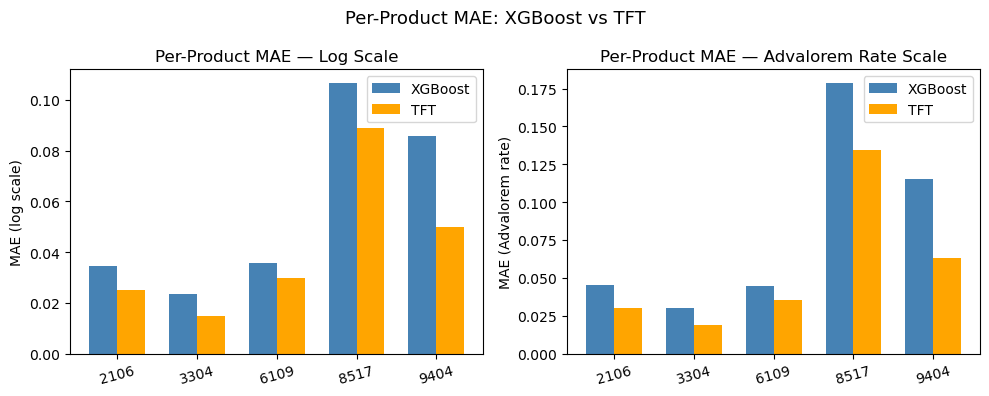

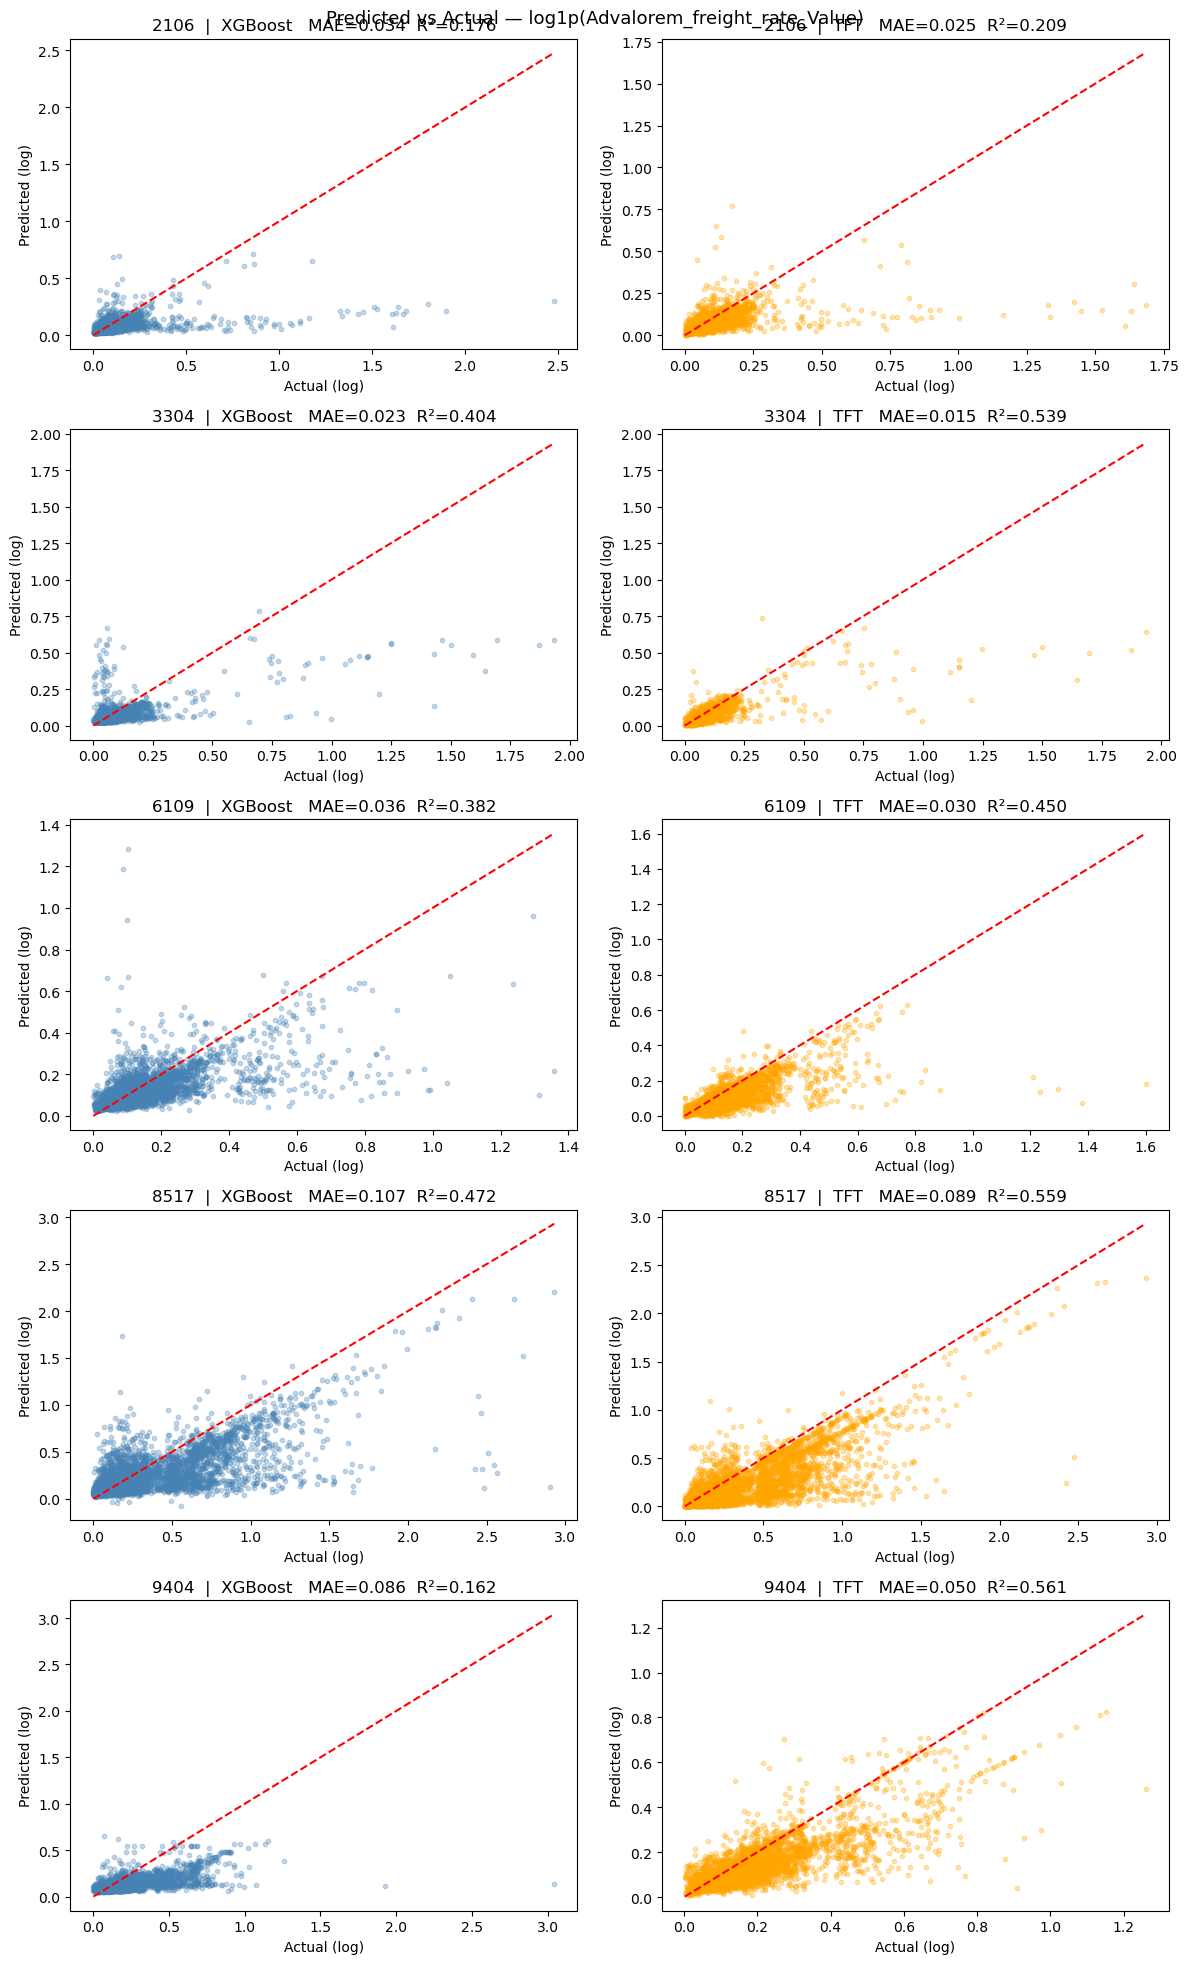

In [56]:

# ── 1. Side-by-side MAE bar chart: XGBoost vs TFT per product ────────────────
_prods    = list(pipeline_results.keys())
_x        = np.arange(len(_prods))
_w        = 0.35
_xgb_mlog = [pipeline_results[p]["xgb_metrics"]["mae_log"]  for p in _prods]
_tft_mlog = [pipeline_results[p]["tft_metrics"]["mae_log"]
             if pipeline_results[p]["tft_metrics"] else float("nan") for p in _prods]
_xgb_musd = [pipeline_results[p]["xgb_metrics"]["mae_usd"]  for p in _prods]
_tft_musd = [pipeline_results[p]["tft_metrics"]["mae_usd"]
             if pipeline_results[p]["tft_metrics"] else float("nan") for p in _prods]

fig, axes = plt.subplots(1, 2, figsize=(max(10, len(_prods) * 2), 4))

axes[0].bar(_x - _w/2, _xgb_mlog, _w, label="XGBoost", color="steelblue")
axes[0].bar(_x + _w/2, _tft_mlog, _w, label="TFT",     color="orange")
axes[0].set_xticks(_x); axes[0].set_xticklabels(_prods, rotation=15)
axes[0].set_ylabel("MAE (log scale)")
axes[0].set_title("Per-Product MAE — Log Scale")
axes[0].legend()

axes[1].bar(_x - _w/2, _xgb_musd, _w, label="XGBoost", color="steelblue")
axes[1].bar(_x + _w/2, _tft_musd, _w, label="TFT",     color="orange")
axes[1].set_xticks(_x); axes[1].set_xticklabels(_prods, rotation=15)
axes[1].set_ylabel("MAE (Advalorem rate)")
axes[1].set_title("Per-Product MAE — Advalorem Rate Scale")
axes[1].legend()

plt.suptitle("Per-Product MAE: XGBoost vs TFT", fontsize=13)
plt.tight_layout()
plt.show()

# ── 2. Predicted vs Actual scatter — one row per product ─────────────────────
_n   = len(pipeline_results)
fig, axes = plt.subplots(_n, 2, figsize=(12, 4 * _n), squeeze=False)

for _i, (_prod, _res) in enumerate(pipeline_results.items()):
    _yt  = _res["df_test"][TARGET].values
    _yxp = _res["xgb_pred"]
    _lo, _hi = float(_yt.min()), float(_yt.max())

    axes[_i, 0].scatter(_yt, _yxp, alpha=0.3, s=10, color="steelblue")
    axes[_i, 0].plot([_lo, _hi], [_lo, _hi], "r--")
    axes[_i, 0].set_title(
        f"{_prod}  |  XGBoost   MAE={_res['xgb_metrics']['mae_log']:.3f}  "
        f"R²={_res['xgb_metrics']['r2_log']:.3f}")
    axes[_i, 0].set_xlabel("Actual (log)"); axes[_i, 0].set_ylabel("Predicted (log)")

    if _res["tft_aligned"] is not None:
        _ya = _res["tft_aligned"][TARGET].values
        _yp = _res["tft_aligned"]["y_pred"].values
        _lo2, _hi2 = float(_ya.min()), float(_ya.max())
        axes[_i, 1].scatter(_ya, _yp, alpha=0.3, s=10, color="orange")
        axes[_i, 1].plot([_lo2, _hi2], [_lo2, _hi2], "r--")
        axes[_i, 1].set_title(
            f"{_prod}  |  TFT   MAE={_res['tft_metrics']['mae_log']:.3f}  "
            f"R²={_res['tft_metrics']['r2_log']:.3f}")
    else:
        axes[_i, 1].text(0.5, 0.5, "TFT skipped\n(< 2 series)",
                         ha="center", va="center", transform=axes[_i, 1].transAxes)
        axes[_i, 1].set_title(f"{_prod}  |  TFT — not run")
    axes[_i, 1].set_xlabel("Actual (log)"); axes[_i, 1].set_ylabel("Predicted (log)")

plt.suptitle("Predicted vs Actual — log1p(Advalorem_freight_rate_Value)", fontsize=13)
plt.tight_layout()
plt.show()


## New Route Prediction — Option A (KNN Analog Imputation)

For a route with **no historical observations**, lag features (`target_lag_1/2/3`, `target_rolling_mean_3`) cannot be computed directly. **Option A** resolves this by:

1. Representing each known route as a vector of time-averaged structural features (`dist_km`, `lsci_sum`, `lsbci`, `GDP_o`, `GDP_d`).
2. Finding the *k* nearest-neighbor routes for the new pair using the pre-fit `route_knn` model for that product.
3. Using the neighbors' mean `y_log` as the lag proxy — a data-driven estimate grounded in structurally similar corridors.

All structural features (distance, LSCI, LSBCI, GDP, GNI, CPI, fuel) are looked up directly from the source tables, so no prior freight observation is required. TFT is **not applicable** for new routes (requires a historical series); only XGBoost is used.


In [57]:
import random

PREDICT_YEAR    = 2022
# ── Set to specific values, or leave None to auto-select ─────────────────────
NEW_ORIGIN      = None   # e.g. "Singapore"
NEW_DESTINATION = None   # e.g. "Brazil"
NEW_PRODUCT     = None   # e.g. leave None to use first available product

# ── Helper: safe label-encoder lookup ────────────────────────────────────────
def _safe_encode(encoder, value):
    classes = list(encoder.classes_)
    return classes.index(value) if value in classes else 0

# ── Helper: look up a scalar value from a reference DataFrame ─────────────────
def _lookup(ref_df, label_col, label_val, year_col, year_val, val_col, fallback):
    row = ref_df[(ref_df[label_col] == label_val) & (ref_df[year_col] == year_val)]
    return float(row[val_col].iloc[0]) if len(row) > 0 else fallback

# ── 1. Select product and a NEW (unseen) O-D pair ────────────────────────────
_available_products = [p for p, r in pipeline_results.items() if r["xgb_model"] is not None]
if not _available_products:
    raise RuntimeError("No products found in pipeline_results — run the pipeline first.")

if NEW_PRODUCT is None:
    NEW_PRODUCT = _available_products[0]

_existing_routes = set(
    zip(
        df_model[df_model["Product_Code"] == NEW_PRODUCT]["Origin_Label"],
        df_model[df_model["Product_Code"] == NEW_PRODUCT]["Destination_Label"],
    )
)

if NEW_ORIGIN is None or NEW_DESTINATION is None:
    # Pick an O-D pair known to label encoders but absent for this product
    _known_origins = list(le_origin.classes_)
    _known_dests   = list(le_dest.classes_)
    _candidates = [
        (o, d) for o in _known_origins for d in _known_dests
        if (o, d) not in _existing_routes and o != d
    ]
    if not _candidates:
        raise RuntimeError("All known O-D combinations already exist for this product.")
    random.seed()
    NEW_ORIGIN, NEW_DESTINATION = random.choice(_candidates)

print(f"New route to predict:")
print(f"  Product    : {NEW_PRODUCT}")
print(f"  Origin     : {NEW_ORIGIN}")
print(f"  Destination: {NEW_DESTINATION}")
print(f"  Year       : {PREDICT_YEAR}")
print(f"  Status     : No historical data in training set")
print()

# ── 2. Assemble structural features from lookup tables ───────────────────────
iso_o = to_iso3(NEW_ORIGIN)
iso_d = to_iso3(NEW_DESTINATION)

feat_raw = {}

# Distance
_d_row = dist2[(dist2["iso_o"] == iso_o) & (dist2["iso_d"] == iso_d)]
feat_raw["dist_km"] = float(_d_row["dist_km"].iloc[0]) if len(_d_row) > 0 else dist_median

# LSBCI
_lb = lsbci2[(lsbci2["iso_o"] == iso_o) & (lsbci2["iso_d"] == iso_d)]
feat_raw["lsbci"] = float(_lb["lsbci"].iloc[0]) if len(_lb) > 0 else 0.0

# LSCI
_lo = lsci_year[(lsci_year["iso3"] == iso_o) & (lsci_year["Year"] == PREDICT_YEAR)]
_ld = lsci_year[(lsci_year["iso3"] == iso_d) & (lsci_year["Year"] == PREDICT_YEAR)]
feat_raw["lsci_o"]   = float(_lo["lsci"].iloc[0]) if len(_lo) > 0 else lsci_global_mean
feat_raw["lsci_d"]   = float(_ld["lsci"].iloc[0]) if len(_ld) > 0 else lsci_global_mean
feat_raw["lsci_sum"] = feat_raw["lsci_o"] + feat_raw["lsci_d"]
feat_raw["lsci_gap"] = abs(feat_raw["lsci_o"] - feat_raw["lsci_d"])

# Fuel
_f_row = fuel_year[fuel_year["Year"] == PREDICT_YEAR]
feat_raw["fuel_vlsfo_avg"] = float(_f_row["fuel_vlsfo_avg"].iloc[0]) if len(_f_row) > 0 else fuel_fill

# CPI
_cpi_fallback = float(df_cpi["Annual_average_growth_rate_Value"].median())
feat_raw["Source_CPI_Annual_average_growth_rate_Value"]      = _lookup(
    df_cpi, "Economy_Label", NEW_ORIGIN,      "Year", PREDICT_YEAR,
    "Annual_average_growth_rate_Value", _cpi_fallback)
feat_raw["Destination_CPI_Annual_average_growth_rate_Value"] = _lookup(
    df_cpi, "Economy_Label", NEW_DESTINATION, "Year", PREDICT_YEAR,
    "Annual_average_growth_rate_Value", _cpi_fallback)

# GDP
_gdp_fallback = float(df_gdp["US_at_current_prices_in_millions_Value"].median())
feat_raw["Source_GDP_US_at_current_prices_in_millions_Value"]      = _lookup(
    df_gdp, "Economy_Label", NEW_ORIGIN,      "Year", PREDICT_YEAR,
    "US_at_current_prices_in_millions_Value", _gdp_fallback)
feat_raw["Destination_GDP_US_at_current_prices_in_millions_Value"] = _lookup(
    df_gdp, "Economy_Label", NEW_DESTINATION, "Year", PREDICT_YEAR,
    "US_at_current_prices_in_millions_Value", _gdp_fallback)

# GNI
_gni_fallback = float(df_gni["US_dollars_at_current_prices_in_millions_Value"].median())
feat_raw["Source_GNI_US_dollars_at_current_prices_in_millions_Value"]      = _lookup(
    df_gni, "Economy_Label", NEW_ORIGIN,      "Year", PREDICT_YEAR,
    "US_dollars_at_current_prices_in_millions_Value", _gni_fallback)
feat_raw["Destination_GNI_US_dollars_at_current_prices_in_millions_Value"] = _lookup(
    df_gni, "Economy_Label", NEW_DESTINATION, "Year", PREDICT_YEAR,
    "US_dollars_at_current_prices_in_millions_Value", _gni_fallback)

# ── Cell 27 Features: Port Throughput (TEU) ──────────────────────────────────
try:
    teu_path = f"{data_path}/../data/raw/container_port_throughput.csv"
    df_teu_pred = pd.read_csv(teu_path)
    df_teu_pred = df_teu_pred[df_teu_pred["Economy_Label"] != "Individual economies"].copy()
    teu_cols = [c for c in df_teu_pred.columns if "TEU_Twenty_foot_Equivalent_Unit_Value" in c and c[:4].isdigit()]
    df_teu_pred = df_teu_pred.melt(id_vars=["Economy_Label"], value_vars=teu_cols, var_name="_col", value_name="teu")
    df_teu_pred["Year"] = df_teu_pred["_col"].str[:4].astype(int)
    df_teu_pred["teu"] = pd.to_numeric(df_teu_pred["teu"], errors="coerce")
    df_teu_pred["iso3"] = df_teu_pred["Economy_Label"].map(to_iso3)
    df_teu_pred = df_teu_pred.dropna(subset=["iso3"])
    
    _teu_o = df_teu_pred[(df_teu_pred["iso3"] == iso_o) & (df_teu_pred["Year"] == PREDICT_YEAR)]
    _teu_d = df_teu_pred[(df_teu_pred["iso3"] == iso_d) & (df_teu_pred["Year"] == PREDICT_YEAR)]
    feat_raw["origin_teu"] = float(_teu_o["teu"].iloc[0]) if len(_teu_o) > 0 and not pd.isna(_teu_o["teu"].iloc[0]) else 0.0
    feat_raw["dest_teu"] = float(_teu_d["teu"].iloc[0]) if len(_teu_d) > 0 and not pd.isna(_teu_d["teu"].iloc[0]) else 0.0
    feat_raw["origin_teu_is_imputed"] = 1 if feat_raw["origin_teu"] == 0.0 else 0
    feat_raw["dest_teu_is_imputed"] = 1 if feat_raw["dest_teu"] == 0.0 else 0
except Exception:
    feat_raw["origin_teu"] = 0.0
    feat_raw["dest_teu"] = 0.0
    feat_raw["origin_teu_is_imputed"] = 1
    feat_raw["dest_teu_is_imputed"] = 1

feat_raw["teu_log_product"] = np.log1p(feat_raw["origin_teu"]) * np.log1p(feat_raw["dest_teu"])

# ── Cell 27 Features: Merchant Fleet ─────────────────────────────────────────
try:
    fleet_path = f"{data_path}/../data/raw/merchant_fleet.csv"
    df_fleet_pred = pd.read_csv(fleet_path)
    df_fleet_pred = df_fleet_pred[df_fleet_pred["Economy_Label"] != "Individual economies"].copy()
    fleet_cols = [c for c in df_fleet_pred.columns if "DWT_Deadweight_tonnage_Value" in c and c[:4].isdigit()]
    df_fleet_pred = df_fleet_pred.melt(id_vars=["Economy_Label"], value_vars=fleet_cols, var_name="_col", value_name="fleet_dwt")
    df_fleet_pred["Year"] = df_fleet_pred["_col"].str[:4].astype(int)
    df_fleet_pred["fleet_dwt"] = pd.to_numeric(df_fleet_pred["fleet_dwt"], errors="coerce")
    df_fleet_pred["iso3"] = df_fleet_pred["Economy_Label"].map(to_iso3)
    df_fleet_pred = df_fleet_pred.dropna(subset=["iso3"])
    
    _fleet_o = df_fleet_pred[(df_fleet_pred["iso3"] == iso_o) & (df_fleet_pred["Year"] == PREDICT_YEAR)]
    _fleet_d = df_fleet_pred[(df_fleet_pred["iso3"] == iso_d) & (df_fleet_pred["Year"] == PREDICT_YEAR)]
    _fleet_total = df_fleet_pred[df_fleet_pred["Year"] == PREDICT_YEAR]["fleet_dwt"].sum()
    feat_raw["origin_fleet_pct"] = (float(_fleet_o["fleet_dwt"].iloc[0]) / _fleet_total * 100) if len(_fleet_o) > 0 and _fleet_total > 0 else 0.0
    feat_raw["dest_fleet_pct"] = (float(_fleet_d["fleet_dwt"].iloc[0]) / _fleet_total * 100) if len(_fleet_d) > 0 and _fleet_total > 0 else 0.0
except Exception:
    feat_raw["origin_fleet_pct"] = 0.0
    feat_raw["dest_fleet_pct"] = 0.0

feat_raw["fleet_supply"] = feat_raw["origin_fleet_pct"] + feat_raw["dest_fleet_pct"]

# ── Cell 27 Features: Seaborne Trade ─────────────────────────────────────────
try:
    trade_path = f"{data_path}/../data/raw/seaborne_trade.csv"
    df_trade_pred = pd.read_csv(trade_path)
    df_trade_pred = df_trade_pred[df_trade_pred["Economy_Label"] != "Individual economies"].copy()
    df_trade_pred["iso3"] = df_trade_pred["Economy_Label"].map(to_iso3)
    df_trade_pred = df_trade_pred.dropna(subset=["iso3"])
    trade_cols = [c for c in df_trade_pred.columns if "_Value" in c and c[:4].isdigit()]
    df_trade_long = df_trade_pred.melt(id_vars=["iso3", "Indicator_Label"], value_vars=trade_cols, var_name="_col", value_name="value")
    df_trade_long["Year"] = df_trade_long["_col"].str[:4].astype(int)
    df_trade_long["value"] = pd.to_numeric(df_trade_long["value"], errors="coerce")
    df_trade_pivot = df_trade_long.pivot_table(index=["iso3", "Year"], columns="Indicator_Label", values="value", aggfunc="first").reset_index()
    
    _trade_o = df_trade_pivot[(df_trade_pivot["iso3"] == iso_o) & (df_trade_pivot["Year"] == PREDICT_YEAR)]
    _trade_d = df_trade_pivot[(df_trade_pivot["iso3"] == iso_d) & (df_trade_pivot["Year"] == PREDICT_YEAR)]
    feat_raw["origin_loaded_kt"] = float(_trade_o["Goods loaded (thousand tonnes)"].iloc[0]) if len(_trade_o) > 0 and "Goods loaded (thousand tonnes)" in _trade_o.columns else 0.0
    feat_raw["origin_discharged_kt"] = float(_trade_o["Goods discharged (thousand tonnes)"].iloc[0]) if len(_trade_o) > 0 and "Goods discharged (thousand tonnes)" in _trade_o.columns else 0.0
    feat_raw["dest_loaded_kt"] = float(_trade_d["Goods loaded (thousand tonnes)"].iloc[0]) if len(_trade_d) > 0 and "Goods loaded (thousand tonnes)" in _trade_d.columns else 0.0
    feat_raw["dest_discharged_kt"] = float(_trade_d["Goods discharged (thousand tonnes)"].iloc[0]) if len(_trade_d) > 0 and "Goods discharged (thousand tonnes)" in _trade_d.columns else 0.0
except Exception:
    feat_raw["origin_loaded_kt"] = 0.0
    feat_raw["origin_discharged_kt"] = 0.0
    feat_raw["dest_loaded_kt"] = 0.0
    feat_raw["dest_discharged_kt"] = 0.0

feat_raw["trade_imbalance"] = (
    (feat_raw["origin_loaded_kt"] - feat_raw["dest_loaded_kt"]) 
    / (feat_raw["origin_loaded_kt"] + feat_raw["dest_loaded_kt"] + 1e-9)
)

# ── Cell 27 Features: Vessel Percentages ─────────────────────────────────────
try:
    vessel_path = f"{data_path}/../data/raw/vessel_percent_of_global_fleet.csv"
    df_vessel_pred = pd.read_csv(vessel_path)
    df_vessel_pred = df_vessel_pred[df_vessel_pred["FlagOfRegistration_Label"] != "Individual economies"].copy()
    vessel_cols = [c for c in df_vessel_pred.columns if "Percentage_of_global_fleet_value_Value" in c and c[:4].isdigit()]
    df_vessel_pred = df_vessel_pred.melt(id_vars=["FlagOfRegistration_Label"], value_vars=vessel_cols, var_name="_col", value_name="vessel_pct")
    df_vessel_pred["Year"] = df_vessel_pred["_col"].str[:4].astype(int)
    df_vessel_pred["vessel_pct"] = pd.to_numeric(df_vessel_pred["vessel_pct"], errors="coerce")
    df_vessel_pred["iso3"] = df_vessel_pred["FlagOfRegistration_Label"].map(to_iso3)
    df_vessel_pred = df_vessel_pred.dropna(subset=["iso3"])
    
    _vessel_o = df_vessel_pred[(df_vessel_pred["iso3"] == iso_o) & (df_vessel_pred["Year"] == PREDICT_YEAR)]
    _vessel_d = df_vessel_pred[(df_vessel_pred["iso3"] == iso_d) & (df_vessel_pred["Year"] == PREDICT_YEAR)]
    feat_raw["origin_vessel_pct"] = float(_vessel_o["vessel_pct"].iloc[0]) if len(_vessel_o) > 0 and not pd.isna(_vessel_o["vessel_pct"].iloc[0]) else 0.0
    feat_raw["dest_vessel_pct"] = float(_vessel_d["vessel_pct"].iloc[0]) if len(_vessel_d) > 0 and not pd.isna(_vessel_d["vessel_pct"].iloc[0]) else 0.0
except Exception:
    feat_raw["origin_vessel_pct"] = 0.0
    feat_raw["dest_vessel_pct"] = 0.0

# ── Cell 27 Features: Historical Mean Rate ───────────────────────────────────
# For new routes, use product median from historical data (2016-2019)
try:
    _hist_subset = df_model[
        (df_model["Product_Code"] == NEW_PRODUCT) & 
        (df_model["Year"].isin([2016, 2017, 2018, 2019]))
    ]
    if len(_hist_subset) > 0:
        feat_raw["historical_mean_rate"] = float(np.expm1(_hist_subset[TARGET].median()))
        feat_raw["historical_mean_rate_is_imputed"] = 1  # Always imputed for new routes
    else:
        feat_raw["historical_mean_rate"] = 0.0
        feat_raw["historical_mean_rate_is_imputed"] = 1
except Exception:
    feat_raw["historical_mean_rate"] = 0.0
    feat_raw["historical_mean_rate_is_imputed"] = 1

# ── Cell 27 Features: Derived Features ───────────────────────────────────────
feat_raw["lsci_asymmetry"] = abs(feat_raw["lsci_o"] - feat_raw["lsci_d"])
feat_raw["post_covid"] = 1 if PREDICT_YEAR >= 2020 else 0
feat_raw["year_int"] = int(PREDICT_YEAR)

# Product category encoding
try:
    _unique_products = sorted(df_model["Product_Code"].unique())
    feat_raw["product_cat"] = int(_unique_products.index(NEW_PRODUCT)) if NEW_PRODUCT in _unique_products else 0
except Exception:
    feat_raw["product_cat"] = 0

# LSBCI imputation flag
feat_raw["bilateral_lsci_is_imputed"] = 1 if feat_raw["lsbci"] == 0.0 else 0

print("Structural features assembled:")
for _fc in FEATURE_COLS:
    print(f"  {_fc:65s}: {feat_raw[_fc]:.4f}")
print()

# ── 3. Option A — KNN analog lag proxy ───────────────────────────────────────
_knn_info = route_knn.get(NEW_PRODUCT)

if _knn_info is not None:
    _query_raw    = np.array([[feat_raw.get(f, 0.0) for f in KNN_FEATS]])
    _query_scaled = _knn_info["knn_scaler"].transform(_query_raw)
    _, _nbr_idx   = _knn_info["knn"].kneighbors(_query_scaled)
    _neighbors    = _knn_info["route_means"].iloc[_nbr_idx[0]]
    _lag_proxy    = float(_neighbors[TARGET].mean())

    print(f"Option A — {len(_nbr_idx[0])} nearest analog route(s):")
    for _, _nr in _neighbors.iterrows():
        print(f"  {_nr['Origin_Label']:25s} → {_nr['Destination_Label']:25s}  "
              f"mean y_log={_nr[TARGET]:.4f}  ({np.expm1(_nr[TARGET]):.4f} Advalorem rate)")
    print(f"\n  Lag proxy (mean of neighbors): {_lag_proxy:.4f}  ({np.expm1(_lag_proxy):.4f} Advalorem rate)")
else:
    _lag_proxy = float(df_model[df_model["Product_Code"] == NEW_PRODUCT][TARGET].median())
    print(f"Option A fallback — product-level median proxy: {_lag_proxy:.4f}  "
          f"({np.expm1(_lag_proxy):.4f} Advalorem rate)")

feat_raw["target_lag_1"]          = _lag_proxy
feat_raw["target_lag_2"]          = _lag_proxy
feat_raw["target_lag_3"]          = _lag_proxy
feat_raw["target_rolling_mean_3"] = _lag_proxy
print()

# ── 4. Scale FEATURE_COLS with the product train-slice scaler ────────────────
_sub_p      = df_model[df_model["Product_Code"] == NEW_PRODUCT]
_df_train_p = _sub_p[_sub_p[TIME_COL] <= split_year]
_scaler     = StandardScaler().fit(_df_train_p[FEATURE_COLS])
_scaled     = _scaler.transform(
    np.array([[feat_raw[c] for c in FEATURE_COLS]])).flatten()

feat_row = {c: float(v) for c, v in zip(FEATURE_COLS, _scaled)}
feat_row["target_lag_1"]          = feat_raw["target_lag_1"]
feat_row["target_lag_2"]          = feat_raw["target_lag_2"]
feat_row["target_lag_3"]          = feat_raw["target_lag_3"]
feat_row["target_rolling_mean_3"] = feat_raw["target_rolling_mean_3"]
feat_row["origin_enc"]            = _safe_encode(le_origin,  NEW_ORIGIN)
feat_row["dest_enc"]              = _safe_encode(le_dest,    NEW_DESTINATION)
feat_row["product_enc"]           = _safe_encode(le_product, str(NEW_PRODUCT))
feat_row[TIME_COL]                = PREDICT_YEAR

X_pred = pd.DataFrame([feat_row])[XGB_FEATURES]

# ── 5. XGBoost prediction ─────────────────────────────────────────────────────
y_log_xgb   = float(pipeline_results[NEW_PRODUCT]["xgb_model"].predict(X_pred)[0])
freight_xgb = np.expm1(y_log_xgb)

print(f"── XGBoost Prediction (New Route, Option A) ─────────────")
print(f"  y_log        : {y_log_xgb:.4f}")
print(f"  Advalorem Rate: {freight_xgb:.4f}")
print()
print("Note: TFT requires a historical time-series and cannot be applied to new routes.")


New route to predict:
  Product    : 2106
  Origin     : Niue
  Destination: Cyprus
  Year       : 2022
  Status     : No historical data in training set

Structural features assembled:
  Source_CPI_Annual_average_growth_rate_Value                      : 2.8450
  Destination_CPI_Annual_average_growth_rate_Value                 : 8.0800
  Source_GDP_US_at_current_prices_in_millions_Value                : 27469.0000
  Destination_GDP_US_at_current_prices_in_millions_Value           : 31218.0000
  Source_GNI_US_dollars_at_current_prices_in_millions_Value        : 24605.0000
  Destination_GNI_US_dollars_at_current_prices_in_millions_Value   : 24605.0000
  lsbci                                                            : 0.0800
  dist_km                                                          : 17140.6900
  fuel_vlsfo_avg                                                   : 828.8692
  lsci_o                                                           : 5.7600
  lsci_d                        

KeyError: 'lsci_product'